In [2]:
from pathlib import Path
import pandas as pd

# Folder relative to this notebook (poster_work/revision.ipynb)
data_dir = Path("../data/csv_files")

# Find CSV files
csv_files = sorted(data_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir.resolve()}")

series_list = []
skipped = []

for f in csv_files:
    try:
        df = pd.read_csv(f)
        # Case-insensitive match for 'discharge'
        cols_lower = {c.lower(): c for c in df.columns}
        if 'discharge' not in cols_lower:
            skipped.append(f.name)
            continue
        s = pd.to_numeric(df[cols_lower['discharge']], errors='coerce')
        series_list.append(s)
    except Exception as e:
        skipped.append(f"{f.name} (error: {e})")

if not series_list:
    raise ValueError("No 'discharge' data found in any CSV.")

# Combine and drop NaNs
all_discharge = pd.concat(series_list, ignore_index=True).dropna()

# Compute Q1 and Q3
q1 = all_discharge.quantile(0.25)
q3 = all_discharge.quantile(0.75)

print(f"Files scanned: {len(csv_files)}")
print(f"Records used: {len(all_discharge)}")
if skipped:
    print(f"Skipped ({len(skipped)}): {', '.join(skipped[:5])}{' ...' if len(skipped) > 5 else ''}")

print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")


Files scanned: 976
Records used: 11924272
Q1 (25th percentile): 0.589
Q3 (75th percentile): 10.08070225116806


In [7]:
from pathlib import Path
import pandas as pd

# Paths relative to the notebook (e.g., poster_work/revision.ipynb)
csv_dir = Path("../data/csv_files")
attributes_path = Path("../metadata/attributes.csv")

# Load attributes: preserve gauge_id as string (to keep leading zeros), area as numeric
attrs = pd.read_csv(attributes_path, dtype={"gauge_id": "string"})
if "gauge_id" not in attrs.columns or "area" not in attrs.columns:
    raise ValueError("attributes.csv must contain 'gauge_id' and 'area' columns.")

attrs["gauge_id"] = attrs["gauge_id"].astype("string").str.strip()
attrs["area"] = pd.to_numeric(attrs["area"], errors="coerce")

# Build a lookup dict for areas; prioritize the first occurrence per gauge_id
attrs = attrs.dropna(subset=["gauge_id"]).drop_duplicates(subset=["gauge_id"], keep="first")
area_by_gauge = dict(zip(attrs["gauge_id"], attrs["area"]))

csv_files = sorted(csv_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {csv_dir.resolve()}")

ratios = []
skipped = []

for f in csv_files:
    gauge_id = f.stem  # filename without extension
    area = area_by_gauge.get(str(gauge_id))

    if area is None or pd.isna(area):
        skipped.append(f"{f.name} (no area for gauge_id={gauge_id})")
        continue
    if area <= 0:
        skipped.append(f"{f.name} (non-positive area={area})")
        continue

    try:
        df = pd.read_csv(f)
    except Exception as e:
        skipped.append(f"{f.name} (read error: {e})")
        continue

    # Find 'discharge' column (case-insensitive); accept exact match or containing 'discharge'
    cols_lower = {c.lower(): c for c in df.columns}
    discharge_col = None
    if "discharge" in cols_lower:
        discharge_col = cols_lower["discharge"]
    else:
        for c in df.columns:
            if "discharge" in str(c).lower():
                discharge_col = c
                break

    if discharge_col is None:
        skipped.append(f"{f.name} (no 'discharge' column)")
        continue

    s = pd.to_numeric(df[discharge_col], errors="coerce").dropna()
    if s.empty:
        skipped.append(f"{f.name} (no numeric discharge values)")
        continue

    mean_discharge = s.mean()
    ratio = mean_discharge / area
    ratios.append(ratio)

if not ratios:
    raise ValueError("No valid mean-discharge-to-area ratios computed. Check skipped reasons.")

ratios_series = pd.Series(ratios, name="mean_discharge_to_area")

q1 = ratios_series.quantile(0.25)
q3 = ratios_series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Files scanned: {len(csv_files)}")
print(f"Ratios computed: {len(ratios_series)}")
if skipped:
    print(f"Skipped ({len(skipped)}): {', '.join(skipped[:5])}{' ...' if len(skipped) > 5 else ''}")

print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR: {iqr}")
print(f"Lower whisker (Q1 - 1.5*IQR): {lower_bound}")
print(f"Upper whisker (Q3 + 1.5*IQR): {upper_bound}")


Files scanned: 976
Ratios computed: 858
Skipped (118): 02AA002.csv (no numeric discharge values), 02AB001.csv (no numeric discharge values), 02AB002.csv (no numeric discharge values), 02AB005.csv (no numeric discharge values), 02AB007.csv (no numeric discharge values) ...
Q1 (25th percentile): 0.008652064193615314
Q3 (75th percentile): 0.014235900142172863
IQR: 0.005583835948557549
Lower whisker (Q1 - 1.5*IQR): 0.0002763102707789896
Upper whisker (Q3 + 1.5*IQR): 0.022611654065009187


In [5]:
from pathlib import Path
import pandas as pd

# Paths relative to the notebook (e.g., poster_work/revision.ipynb)
csv_dir = Path("../data/csv_files")
attributes_path = Path("../metadata/attributes.csv")

# Load attributes: preserve gauge_id as string (to keep leading zeros), area as numeric
attrs = pd.read_csv(attributes_path, dtype={"gauge_id": "string"})
if "gauge_id" not in attrs.columns or "area" not in attrs.columns:
    raise ValueError("attributes.csv must contain 'gauge_id' and 'area' columns.")

attrs["gauge_id"] = attrs["gauge_id"].astype("string").str.strip()
attrs["area"] = pd.to_numeric(attrs["area"], errors="coerce")

# Build a lookup dict for areas; prioritize the first occurrence per gauge_id
attrs = attrs.dropna(subset=["gauge_id"]).drop_duplicates(subset=["gauge_id"], keep="first")
area_by_gauge = dict(zip(attrs["gauge_id"], attrs["area"]))

csv_files = sorted(csv_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {csv_dir.resolve()}")

ratios = []
skipped = []

for f in csv_files:
    gauge_id = f.stem  # filename without extension
    area = area_by_gauge.get(str(gauge_id))

    if area is None or pd.isna(area):
        skipped.append(f"{f.name} (no area for gauge_id={gauge_id})")
        continue
    if area <= 0:
        skipped.append(f"{f.name} (non-positive area={area})")
        continue

    try:
        df = pd.read_csv(f)
    except Exception as e:
        skipped.append(f"{f.name} (read error: {e})")
        continue

    # Find 'discharge' column (case-insensitive); accept exact match or containing 'discharge'
    cols_lower = {c.lower(): c for c in df.columns}
    discharge_col = None
    if "discharge" in cols_lower:
        discharge_col = cols_lower["discharge"]
    else:
        for c in df.columns:
            if "discharge" in str(c).lower():
                discharge_col = c
                break

    if discharge_col is None:
        skipped.append(f"{f.name} (no 'discharge' column)")
        continue

    s = pd.to_numeric(df[discharge_col], errors="coerce").dropna()
    if s.empty:
        skipped.append(f"{f.name} (no numeric discharge values)")
        continue

    median_discharge = s.median()
    ratio = median_discharge / area
    ratios.append(ratio)

if not ratios:
    raise ValueError("No valid median-discharge-to-area ratios computed. Check skipped reasons.")

ratios_series = pd.Series(ratios, name="median_discharge_to_area")

q1 = ratios_series.quantile(0.25)
q3 = ratios_series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Files scanned: {len(csv_files)}")
print(f"Ratios computed: {len(ratios_series)}")
if skipped:
    print(f"Skipped ({len(skipped)}): {', '.join(skipped[:5])}{' ...' if len(skipped) > 5 else ''}")

print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR: {iqr}")
print(f"Lower whisker (Q1 - 1.5*IQR): {lower_bound}")
print(f"Upper whisker (Q3 + 1.5*IQR): {upper_bound}")


Files scanned: 976
Ratios computed: 858
Skipped (118): 02AA002.csv (no numeric discharge values), 02AB001.csv (no numeric discharge values), 02AB002.csv (no numeric discharge values), 02AB005.csv (no numeric discharge values), 02AB007.csv (no numeric discharge values) ...
Q1 (25th percentile): 0.004723335460576873
Q3 (75th percentile): 0.009934877591202125
IQR: 0.005211542130625252
Lower whisker (Q1 - 1.5*IQR): -0.003093977735361005
Upper whisker (Q3 + 1.5*IQR): 0.017752190787140004


In [8]:
ratios_series.describe()

count    858.000000
mean       0.017668
std        0.082627
min        0.000537
25%        0.008652
50%        0.011153
75%        0.014236
max        1.910970
Name: mean_discharge_to_area, dtype: float64

In [11]:
from pathlib import Path
import pandas as pd

# Progress bar
try:
    from tqdm.notebook import tqdm
except Exception:
    try:
        from tqdm import tqdm
    except Exception:
        def tqdm(x, **kwargs):  # fallback
            return x

# Paths relative to this notebook (poster_work/revision.ipynb)
csv_dir = Path("../data/csv_files")

# Thresholds for run length
thresholds = [7, 14, 21]

def find_discharge_column(df: pd.DataFrame) -> str | None:
    if df.empty or df.columns.empty:
        return None
    lower_map = {str(c).lower(): c for c in df.columns}
    if "discharge" in lower_map:
        return lower_map["discharge"]
    for c in df.columns:
        if "discharge" in str(c).lower():
            return c
    return None

def count_rows_in_constant_runs(values: pd.Series, thresholds):
    # Coerce to numeric; NaNs break runs
    s = pd.to_numeric(values, errors="coerce")
    if s.empty:
        return {t: 0 for t in thresholds}, 0

    # Identify consecutive-equal segments; NaNs form their own breaks
    groups = s.ne(s.shift()).cumsum()
    run_sizes = s.groupby(groups).transform("size")
    valid_runs = run_sizes[s.notna()]  # ignore NaNs

    counts = {t: int((valid_runs >= t).sum()) for t in thresholds}
    total_valid = int(s.notna().sum())
    return counts, total_valid

# Gather files
csv_files = sorted(csv_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {csv_dir.resolve()}")

global_counts = {t: 0 for t in thresholds}
total_rows_considered = 0
files_scanned = 0

for f in tqdm(csv_files, desc=f"Scanning {csv_dir}", unit="file"):
    try:
        df = pd.read_csv(f)
    except Exception:
        continue  # skip unreadable files
    col = find_discharge_column(df)
    if col is None:
        continue

    counts, valid_rows = count_rows_in_constant_runs(df[col], thresholds)
    for t in thresholds:
        global_counts[t] += counts[t]
    total_rows_considered += valid_rows
    files_scanned += 1

print("Row counts belonging to constant discharge runs (≥ threshold):")
for t in thresholds:
    print(f"  ≥ {t} days: {global_counts[t]} rows")

print(f"\nFiles scanned: {files_scanned}")
print(f"Total non-NaN discharge rows considered: {total_rows_considered}")


Scanning ..\data\csv_files:   0%|          | 0/976 [00:00<?, ?file/s]

Row counts belonging to constant discharge runs (≥ threshold):
  ≥ 7 days: 2501461 rows
  ≥ 14 days: 2446599 rows
  ≥ 21 days: 2429971 rows

Files scanned: 975
Total non-NaN discharge rows considered: 11924272


In [12]:
2501461/11924272

0.20977892822303953

In [13]:
2446599/11924272

0.20517806034615782

In [14]:
2429971/11924272

0.20378359366508916

In [15]:
from pathlib import Path
import pandas as pd

# Progress bar
try:
    from tqdm.notebook import tqdm
except Exception:
    try:
        from tqdm import tqdm
    except Exception:
        def tqdm(x, **kwargs):  # fallback
            return x

# Paths relative to this notebook (poster_work/revision.ipynb)
csv_dir = Path("../data/csv_files")

# Thresholds for run length
thresholds = [7, 14, 21]

# Date range (inclusive)
start_date = pd.Timestamp("1980-01-01")
end_date   = pd.Timestamp("2012-12-31")

def find_discharge_column(df: pd.DataFrame) -> str | None:
    if df.empty or df.columns.empty:
        return None
    lower_map = {str(c).lower(): c for c in df.columns}
    if "discharge" in lower_map:
        return lower_map["discharge"]
    for c in df.columns:
        if "discharge" in str(c).lower():
            return c
    return None

def find_date_column(df: pd.DataFrame) -> str | None:
    # Prefer exact 'date' (case-insensitive), else any column containing 'date'
    if df.empty or df.columns.empty:
        return None
    lower_map = {str(c).lower(): c for c in df.columns}
    if "date" in lower_map:
        return lower_map["date"]
    for c in df.columns:
        if "date" in str(c).lower():
            return c
    return None

def count_rows_in_constant_runs(values: pd.Series, thresholds):
    # Coerce to numeric; NaNs break runs
    s = pd.to_numeric(values, errors="coerce")
    if s.empty:
        return {t: 0 for t in thresholds}, 0

    # Identify consecutive-equal segments; NaNs form their own breaks
    groups = s.ne(s.shift()).cumsum()
    run_sizes = s.groupby(groups).transform("size")
    valid_runs = run_sizes[s.notna()]  # ignore NaNs

    counts = {t: int((valid_runs >= t).sum()) for t in thresholds}
    total_valid = int(s.notna().sum())
    return counts, total_valid

# Gather files
csv_files = sorted(csv_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {csv_dir.resolve()}")

global_counts = {t: 0 for t in thresholds}
total_rows_considered = 0
files_scanned = 0

for f in tqdm(csv_files, desc=f"Scanning {csv_dir}", unit="file"):
    try:
        df = pd.read_csv(f)
    except Exception:
        continue  # skip unreadable files

    date_col = find_date_column(df)
    discharge_col = find_discharge_column(df)
    if date_col is None or discharge_col is None:
        continue

    # Parse dates and filter to range
    dates = pd.to_datetime(df[date_col], errors="coerce")
    mask = dates.between(start_date, end_date, inclusive="both")
    if not mask.any():
        continue

    # Sort by date to ensure chronological order, then filter
    df = df.assign(_date_=dates).sort_values("_date_")
    df = df.loc[df["_date_"].between(start_date, end_date, inclusive="both")]

    if df.empty:
        continue

    counts, valid_rows = count_rows_in_constant_runs(df[discharge_col], thresholds)
    for t in thresholds:
        global_counts[t] += counts[t]
    total_rows_considered += valid_rows
    files_scanned += 1

print("Row counts in constant discharge runs within 1980-01-01 to 2012-12-31 (≥ threshold):")
for t in thresholds:
    print(f"  ≥ {t} days: {global_counts[t]} rows")

print(f"\nFiles scanned: {files_scanned}")
print(f"Total non-NaN discharge rows considered (within range): {total_rows_considered}")


Scanning ..\data\csv_files:   0%|          | 0/976 [00:00<?, ?file/s]

Row counts in constant discharge runs within 1980-01-01 to 2012-12-31 (≥ threshold):
  ≥ 7 days: 1492922 rows
  ≥ 14 days: 1443975 rows
  ≥ 21 days: 1429455 rows

Files scanned: 975
Total non-NaN discharge rows considered (within range): 8533255


In [16]:
1492922/8533255

0.1749534028925656

In [17]:
1443975/8533255

0.16921737367510992

In [18]:
1429455/8533255

0.1675157955551545

## For Seed 2024

In [3]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EA-LSTM_Basin_Normalized_Seed2004_1009_210936" # Specify the model name
epoch_num = 12 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/basin_list_complete.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/2013",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator)

  0%|          | 0/975 [00:00<?, ?it/s]

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/975 [00:00<02:00,  8.10it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarni

Summary for: evaluate EA-LSTM_Basin_Normalized_Seed2004_1009_210936 epoch 12

NSE Summary Statistics: 
count    647.000000
mean      -0.120000
std        9.216689
min     -227.737512
25%        0.328675
50%        0.464448
75%        0.589821
max        0.816364
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    647.000000
mean       0.411108
std        0.655447
min      -13.613524
25%        0.324477
50%        0.481453
75%        0.626378
max        0.866107
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Good              450
N/A               328
Unsatisfactory    160
Negative           30
Excellent           7
Name: count, dtype: int64

evaluate EA-LSTM_Basin_Normalized_Seed2004_1009_210936 epoch 12


In [4]:
seed_2004_test = pd.read_csv("runs/EA-LSTM_Basin_Normalized_Seed2004_1009_210936/test/model_epoch012/test_metrics.csv")
print(seed_2004_test.describe())

              NSE          KGE
count  647.000000   647.000000
mean     0.343280    -3.188483
std      2.397303    62.221839
min    -46.917736 -1563.462092
25%      0.498792    -0.088249
50%      0.628436     0.448762
75%      0.710191     0.640014
max      0.880710     0.854980


## For Seed 2005

In [5]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EA-LSTM_Basin_Normalized_Seed2025_1009_131016" # Specify the model name
epoch_num = 14 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/regional_test.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/2013",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator)

  0%|          | 0/195 [00:00<?, ?it/s]

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  1%|          | 1/195 [00:00<00:34,  5.62it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarni

Summary for: evaluate EA-LSTM_Basin_Normalized_Seed2025_1009_131016 epoch 14

NSE Summary Statistics: 
count    134.000000
mean       0.281281
std        1.799125
min      -20.152487
25%        0.336429
50%        0.485431
75%        0.584494
max        0.755230
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    134.000000
mean       0.439746
std        0.235487
min       -0.244479
25%        0.287661
50%        0.463028
75%        0.617048
max        0.837801
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Good              95
N/A               61
Unsatisfactory    34
Negative           4
Excellent          1
Name: count, dtype: int64

evaluate EA-LSTM_Basin_Normalized_Seed2025_1009_131016 epoch 14


In [5]:
import pandas as pd
seed_2005_test = pd.read_csv("runs/EA-LSTM_Basin_Normalized_Seed2025_1009_131016/test/model_epoch014/test_metrics.csv")
print(seed_2005_test.describe())

              NSE         KGE
count  647.000000  647.000000
mean     0.278254   -1.546243
std      2.872914   13.068273
min    -55.412601 -195.260232
25%      0.485267   -0.244304
50%      0.638787    0.426463
75%      0.725484    0.655390
max      0.845339    0.899061


## With No Static Attributes

In [8]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "LSTM_No_Static_1109_023854" # Specify the model name
epoch_num = 9 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/complete_basin_list.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/2013",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

  0%|          | 0/975 [00:00<?, ?it/s]

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/975 [00:00<03:45,  4.31it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarni

In [ ]:
evaluator

In [7]:
print(evaluator)

Summary for: evaluate EALSTM_No_Static_Regional_1509_120535 epoch 6

NSE Summary Statistics: 
count    168.000000
mean      -5.201172
std       31.260561
min     -250.437379
25%        0.123017
50%        0.284095
75%        0.408071
max        0.647371
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    168.000000
mean      -0.050176
std        2.087140
min      -14.870343
25%        0.179989
50%        0.330254
75%        0.481317
max        0.774825
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Unsatisfactory    78
Good              58
Negative          32
N/A               27
Name: count, dtype: int64

evaluate EALSTM_No_Static_Regional_1509_120535 epoch 6


In [6]:
lstm_no_static = pd.read_csv("runs/LSTM_No_Static_1109_023854/test/model_epoch009/test_metrics.csv")
print(lstm_no_static.describe())

              NSE
count  647.000000
mean    -2.181715
std     11.809080
min   -194.116791
25%     -0.985804
50%      0.021575
75%      0.301730
max      0.781946


In [14]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EALSTM_No_Static_1209_032915" # Specify the model name
epoch_num = 25 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/complete_basin_list.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=False,
                      test_start_date="01/01/2013",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\neuralhydrology\evaluation\tester.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub f

# Evaluation: 100%|██████████| 975/975 [08:21<00:00,  1.94it/s]


  0%|          | 0/975 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/975 [00:00<03:33,  4.57it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

In [15]:
print(evaluator)

Summary for: evaluate EALSTM_No_Static_1209_032915 epoch 25

NSE Summary Statistics: 
count    647.000000
mean      -1.563140
std       17.506577
min     -345.429944
25%        0.104757
50%        0.241876
75%        0.353598
max        0.657868
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    647.000000
mean       0.160343
std        1.102370
min      -16.681671
25%        0.141432
50%        0.298541
75%        0.451856
max        0.807572
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Unsatisfactory    376
N/A               328
Good              157
Negative          114
Name: count, dtype: int64

evaluate EALSTM_No_Static_1209_032915 epoch 25


In [1]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EALSTM_No_Static_Regional_1509_120535" # Specify the model name
epoch_num = 6 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/regional_test.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=False,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator)

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\neuralhydrology\evaluation\tester.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub f

# Evaluation: 100%|██████████| 195/195 [05:26<00:00,  1.67s/it]


  0%|          | 0/195 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  4%|▎         | 7/195 [00:01<00:43,  4.29it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

Summary for: evaluate EALSTM_No_Static_Regional_1509_120535 epoch 6

NSE Summary Statistics: 
count    168.000000
mean      -5.201172
std       31.260561
min     -250.437379
25%        0.123017
50%        0.284095
75%        0.408071
max        0.647371
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    168.000000
mean      -0.050176
std        2.087140
min      -14.870343
25%        0.179989
50%        0.330254
75%        0.481317
max        0.774825
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Unsatisfactory    78
Good              58
Negative          32
N/A               27
Name: count, dtype: int64

evaluate EALSTM_No_Static_Regional_1509_120535 epoch 6


## Main Model

In [13]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EA-LSTM_Basin_Normalized_2706_143800" # Specify the model name
epoch_num = 33 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/complete_basin_list.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/2013",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator)

  0%|          | 0/975 [00:00<?, ?it/s]

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/975 [00:00<01:52,  8.65it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarni

Summary for: evaluate EA-LSTM_Basin_Normalized_2706_143800 epoch 33

NSE Summary Statistics: 
count    647.000000
mean      -0.012294
std       11.037452
min     -274.497576
25%        0.530759
50%        0.684652
75%        0.768132
max        0.897667
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    647.000000
mean       0.579713
std        0.710804
min      -15.072587
25%        0.523412
50%        0.678239
75%        0.792069
max        0.933572
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Good              362
N/A               328
Excellent         204
Unsatisfactory     51
Negative           30
Name: count, dtype: int64

evaluate EA-LSTM_Basin_Normalized_2706_143800 epoch 33


In [3]:
extreme_metrics = evaluator.evaluate_extremes()

Evaluating extreme event metrics...


  0%|          | 0/975 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/975 [00:00<01:43,  9.39it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

In [4]:
extreme_metrics.to_csv("notebooks/results/EALSTM_temporal_extrmeme_result.csv")

In [7]:
extreme_metrics

,basin_id,PBIAS_high,FHV,PBIAS_low,FLV
0,02AA001,NaN,NaN,NaN,NaN
1,02AA002,NaN,NaN,NaN,NaN
2,02AB001,NaN,NaN,NaN,NaN
3,02AB002,NaN,NaN,NaN,NaN
4,02AB004,NaN,NaN,NaN,NaN
...,...,...,...,...,...
970,04257000,NaN,NaN,NaN,NaN
971,04258000,-35.350575,0.080747,68.888737,0.066051
972,04260500,-5.770725,0.156050,21.934070,0.030841
973,04263000,-16.664960,0.151861,61.349259,0.026911


In [8]:
exclude_ids = {
    "02DD030", "04073473", "02AB025", "04149000", "04102776",
    "04106500", "02CC008", "04150500", "04106320", "04145000",
    "02HB030", "02GD022", "04232100", "02GC021", "02GA050",
}

print(extreme_metrics.loc[~extreme_metrics["basin_id"].isin(exclude_ids)].describe())


       PBIAS_high         FHV    PBIAS_low         FLV
count  632.000000  632.000000   632.000000  632.000000
mean   -30.678475    0.178302    91.728375    0.026570
std     23.848786    0.069306   412.393731    0.022075
min    -88.121622    0.025958   -70.659976    0.000608
25%    -42.203627    0.124539     6.539746    0.010072
50%    -29.556313    0.172360    22.839724    0.022663
75%    -18.744823    0.221890    62.114758    0.037532
max    379.294580    0.645856  8680.658544    0.255152


In [11]:
metrics = evaluator.get_metrics()
print(metrics)

     basin_id       NSE       KGE Performance
0     02AA001       NaN       NaN         N/A
1     02AA002       NaN       NaN         N/A
2     02AB001       NaN       NaN         N/A
3     02AB002       NaN       NaN         N/A
4     02AB004       NaN       NaN         N/A
..        ...       ...       ...         ...
970  04257000       NaN       NaN         N/A
971  04258000  0.459031  0.524400        Good
972  04260500  0.826343  0.907997   Excellent
973  04263000  0.820073  0.850678   Excellent
974  05535070  0.756369  0.650463   Excellent

[975 rows x 4 columns]


In [12]:
metrics

,basin_id,NSE,KGE,Performance
0,02AA001,NaN,NaN,N/A
1,02AA002,NaN,NaN,N/A
2,02AB001,NaN,NaN,N/A
3,02AB002,NaN,NaN,N/A
4,02AB004,NaN,NaN,N/A
...,...,...,...,...
970,04257000,NaN,NaN,N/A
971,04258000,0.459031,0.524400,Good
972,04260500,0.826343,0.907997,Excellent
973,04263000,0.820073,0.850678,Excellent


In [68]:
metrics.to_csv("EALSTM_temporal_result_filtered.csv")

--- Analysis of Extreme Negative Outliers ---
Identifying outliers with NSE <= 0.148 (32 basins)

Characteristics of the 10 worst-performing basins:
     basin_id        NSE          area  urb_pc_sse  crp_pc_sse  for_pc_sse  \
69    02DD031 -46.461361  13916.762286    0.290545    0.999497   86.620295   
472  04123500 -10.702620    336.694059    0.000000    5.005792   79.534110   
544  04183500  -1.790110   5365.497401    5.472756   71.161003    1.951133   
175   02GA045  -1.100267      4.848310    3.000000   68.765480    0.000000   
259   02HB031  -0.724255     12.797827    1.813303   31.062059   19.952344   
25    02BE002  -0.626973   2967.078061    0.000000    0.000000   77.716467   
292   02HD021  -0.558014     23.139442    3.358904   37.205586   18.285869   
478  04126740  -0.312254    324.237471    0.029293   17.758963   76.327740   
498  04152500  -0.263081   1100.926722    0.000000   19.885554   47.264104   
220   02GE007  -0.158091    205.347565    1.569457   92.862200    0.000

C:\Users\ybrot\AppData\Local\Temp\ipykernel_701436\25194500.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='area_bin', y='NSE', data=data, ax=ax, palette='viridis', cut=0)


Successfully generated and saved 'nse_distribution_by_area_violin.png'


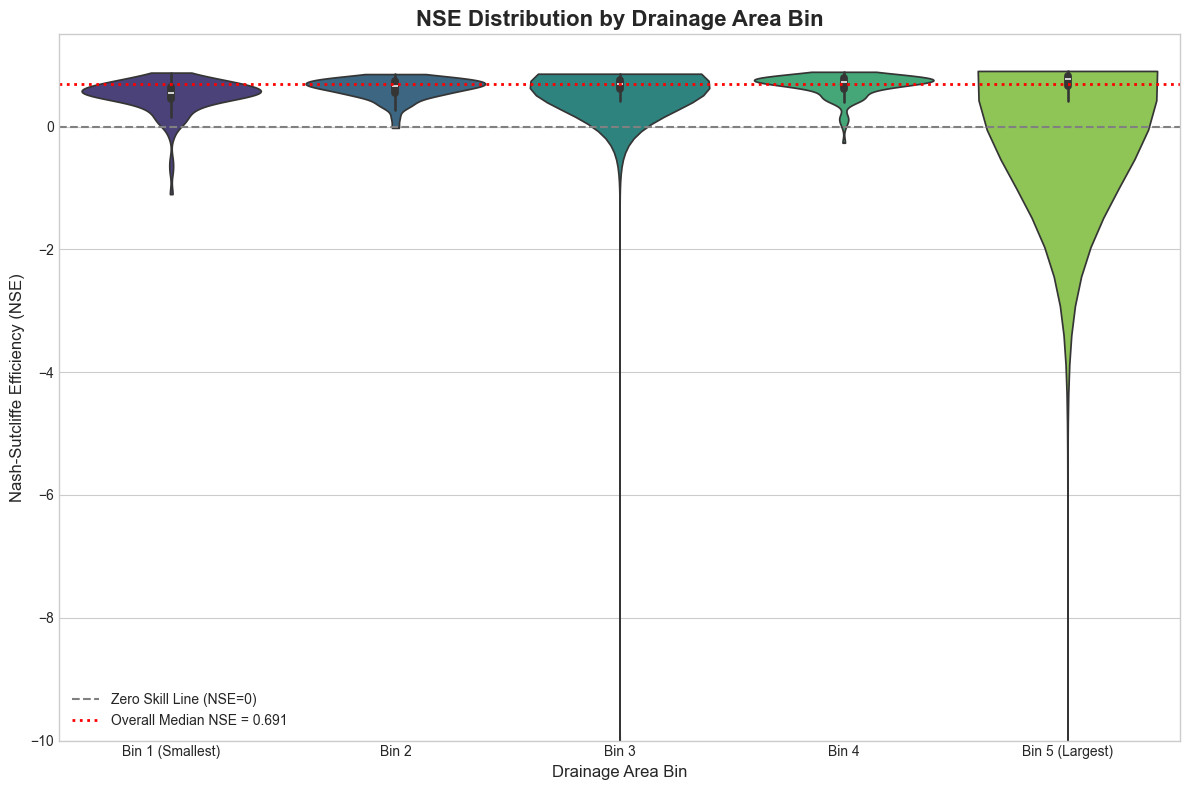

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import trim_mean

# --- 1. Load YOUR Actual Data ---
# IMPORTANT: This section must be run in your local environment where your data exists.

# A. Load the performance metrics from your evaluator object
# Make sure to drop rows with no NSE data to avoid errors in calculations
# evaluator = ... (this object should already be defined in your environment)
metrics = evaluator.get_metrics()[['basin_id', 'NSE']].dropna()

# B. Load the basin attributes from your CSV file
try:
    attributes = pd.read_csv('metadata/attributes.csv')
except FileNotFoundError:
    print("ERROR: Could not find 'metadata/attributes.csv'. Please ensure the file path is correct.")
    # Exit or handle the error as needed if the file isn't found
    exit()

# --- 2. Merge DataFrames ---
# Merge the performance metrics with the basin attributes
# 'gauge_id' in attributes.csv should correspond to 'basin_id' in metrics
data = pd.merge(metrics, attributes, left_on='basin_id', right_on='gauge_id', how='left')

if data['area'].isnull().any():
    print("Warning: Some basins in the metrics were not found in the attributes file.")
    print("Proceeding with the successfully merged basins.")
    data.dropna(subset=['area'], inplace=True)


# --- 3. Analyze Outliers and Causal Patterns ---
print("--- Analysis of Extreme Negative Outliers ---")
# Define outliers based on a percentile (e.g., bottom 5%)
outlier_threshold = data['NSE'].quantile(0.05)
outliers = data[data['NSE'] <= outlier_threshold].sort_values('NSE')
print(f"Identifying outliers with NSE <= {outlier_threshold:.3f} ({len(outliers)} basins)\n")

# Display characteristics of the 10 worst-performing basins
print("Characteristics of the 10 worst-performing basins:")
# Add any other relevant columns from your attributes file here
outlier_characteristics = outliers.head(10)[['basin_id', 'NSE', 'area', 'urb_pc_sse', 'crp_pc_sse', 'for_pc_sse', 'dor_pc_pva']]
print(outlier_characteristics)


# --- 4. Calculate Robust Statistics ---
print("\n--- Robust Aggregation Statistics ---")
original_mean = data['NSE'].mean()
median_nse = data['NSE'].median()
# Calculate 10% trimmed mean (removes 10% from each end)
trimmed_mean_10 = trim_mean(data['NSE'].dropna(), 0.1)

print(f"Original Mean NSE: {original_mean:.3f}")
print(f"Median NSE: {median_nse:.3f}")
print(f"10% Trimmed Mean NSE: {trimmed_mean_10:.3f}")


# --- 5. Visualization as Requested by Reviewer ---
print("\nGenerating visualization...")

# Create the same drainage area bins as in your paper for a consistent comparison
data['area_bin'] = pd.qcut(data['area'], 5, labels=["Bin 1 (Smallest)", "Bin 2", "Bin 3", "Bin 4", "Bin 5 (Largest)"])

# Set a professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Create the violin plot to show the density distribution for each area bin
sns.violinplot(x='area_bin', y='NSE', data=data, ax=ax, palette='viridis', cut=0)

ax.set_title('NSE Distribution by Drainage Area Bin', fontsize=16, fontweight='bold')
ax.set_xlabel('Drainage Area Bin', fontsize=12)
ax.set_ylabel('Nash-Sutcliffe Efficiency (NSE)', fontsize=12)

# Add reference lines
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5, label='Zero Skill Line (NSE=0)')
ax.axhline(median_nse, color='red', linestyle=':', linewidth=2, label=f"Overall Median NSE = {median_nse:.3f}")

# Zoom in to see the bulk of the distribution, but adjust if your min values are different
# You can comment this out to see the full range of the y-axis
ax.set_ylim(-10, 1.5)

plt.legend()
plt.tight_layout()
plt.savefig('nse_distribution_by_area_violin.png', dpi=300)

print("Successfully generated and saved 'nse_distribution_by_area_violin.png'")


Generating improved visualization using a box plot...


C:\Users\ybrot\AppData\Local\Temp\ipykernel_701436\2922813652.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='area_bin', y='NSE', data=data, ax=ax, palette='viridis',


Successfully generated and saved 'nse_distribution_by_area_boxplot.png'


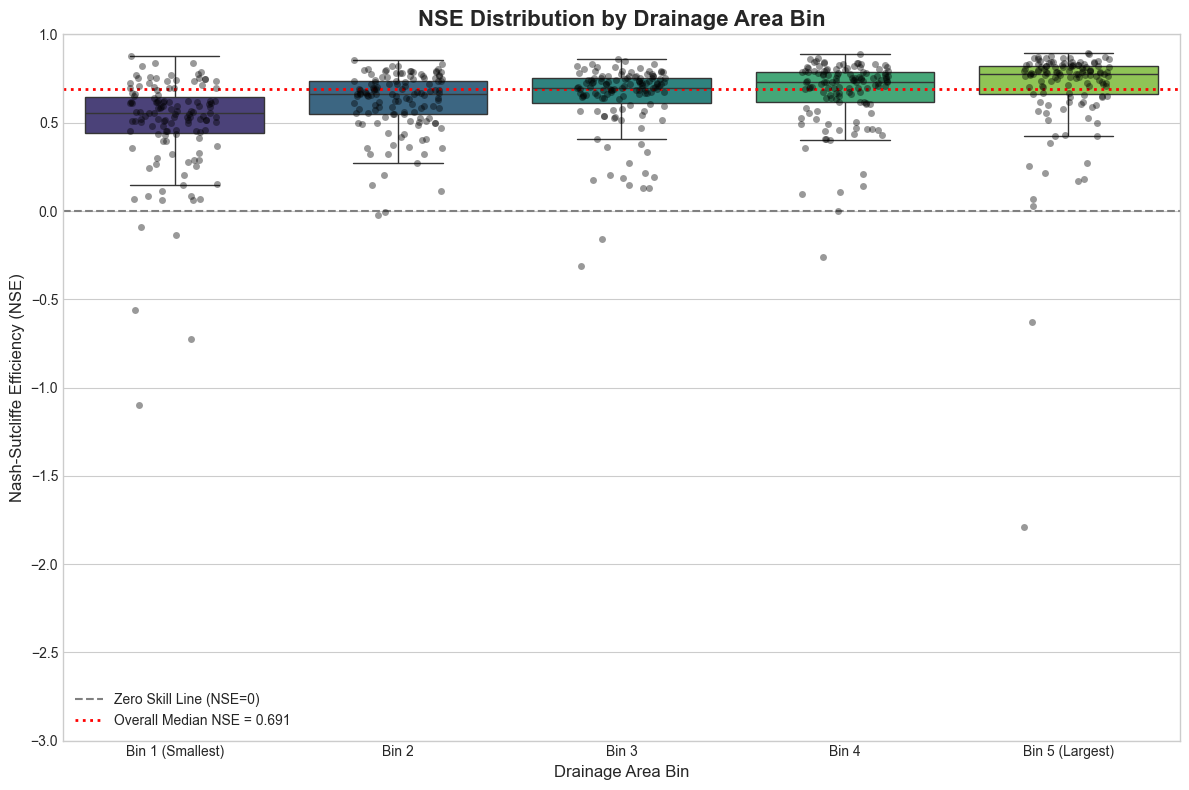

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import trim_mean

# --- This section is the same as before: Load and process your data ---

# A. Load metrics from your evaluator object
# evaluator = ... (should be defined in your environment)
metrics = evaluator.get_metrics()[['basin_id', 'NSE']].dropna()

# B. Load basin attributes
attributes = pd.read_csv('metadata/attributes.csv')

# C. Merge DataFrames
data = pd.merge(metrics, attributes, left_on='basin_id', right_on='gauge_id', how='left')
data.dropna(subset=['area'], inplace=True)

# D. Create drainage area bins
data['area_bin'] = pd.qcut(data['area'], 5, labels=["Bin 1 (Smallest)", "Bin 2", "Bin 3", "Bin 4", "Bin 5 (Largest)"])


# --- 4. Revised Visualization (Using a Box Plot) ---
print("\nGenerating improved visualization using a box plot...")

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# --- Create the Box Plot ---
sns.boxplot(x='area_bin', y='NSE', data=data, ax=ax, palette='viridis',
            showfliers=False) # 'showfliers=False' hides outliers from the boxplot itself

# --- Overlay a Stripplot to explicitly show all points, including outliers ---
sns.stripplot(x='area_bin', y='NSE', data=data, ax=ax, color='black', alpha=0.4, jitter=0.2)


ax.set_title('NSE Distribution by Drainage Area Bin', fontsize=16, fontweight='bold')
ax.set_xlabel('Drainage Area Bin', fontsize=12)
ax.set_ylabel('Nash-Sutcliffe Efficiency (NSE)', fontsize=12)

# Add reference lines
ax.axhline(0, color='grey', linestyle='--', linewidth=1.5, label='Zero Skill Line (NSE=0)')
ax.axhline(data['NSE'].median(), color='red', linestyle=':', linewidth=2, label=f"Overall Median NSE = {data['NSE'].median():.3f}")

# Set a reasonable Y-axis limit to focus on the main distributions
ax.set_ylim(-3, 1.0) # We can adjust this if needed, but it's a good starting point

plt.legend()
plt.tight_layout()
plt.savefig('nse_distribution_by_area_boxplot.png', dpi=300)

print("Successfully generated and saved 'nse_distribution_by_area_boxplot.png'")

In [13]:
metrics[metrics['NSE'] == metrics['NSE'].min()]

,basin_id,NSE,KGE,Performance
140,02DD030,-274.497576,-15.072587,Negative


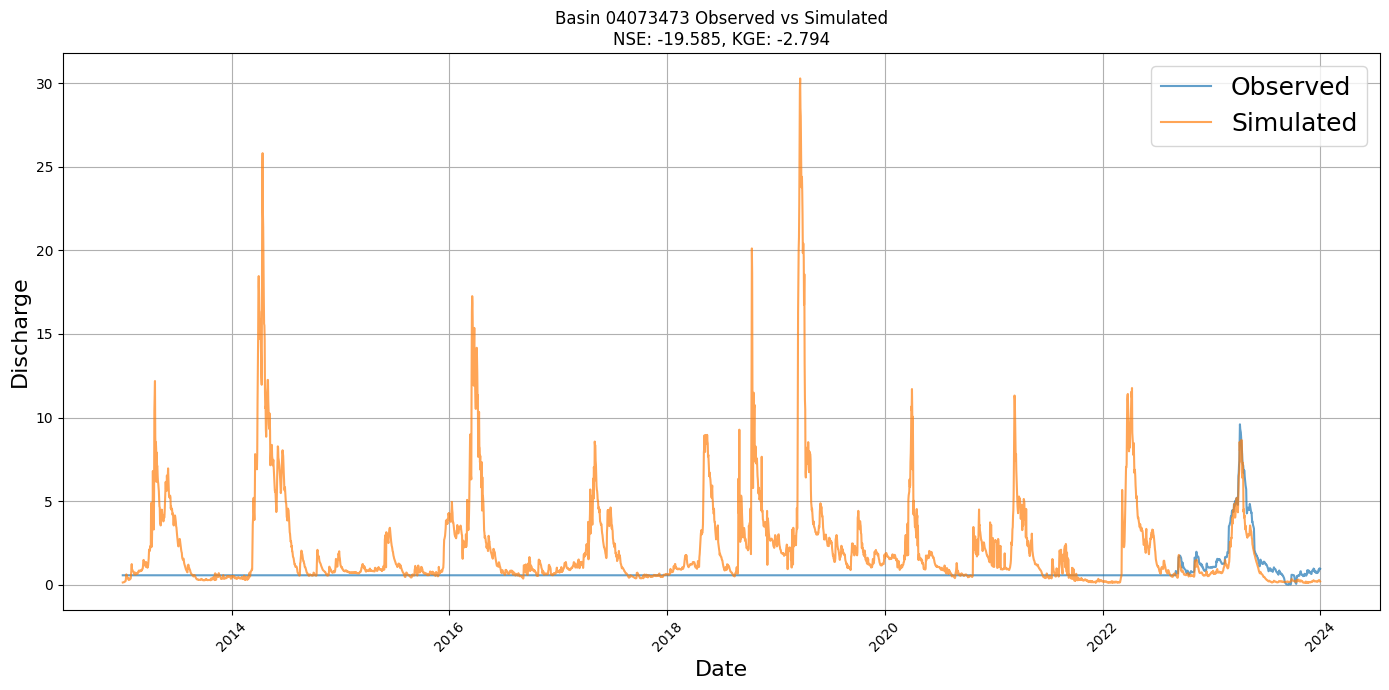

In [15]:
evaluator.plot_prediction('04073473', legend_fontsize=18, x_label_fontsize=16, y_label_fontsize=16)

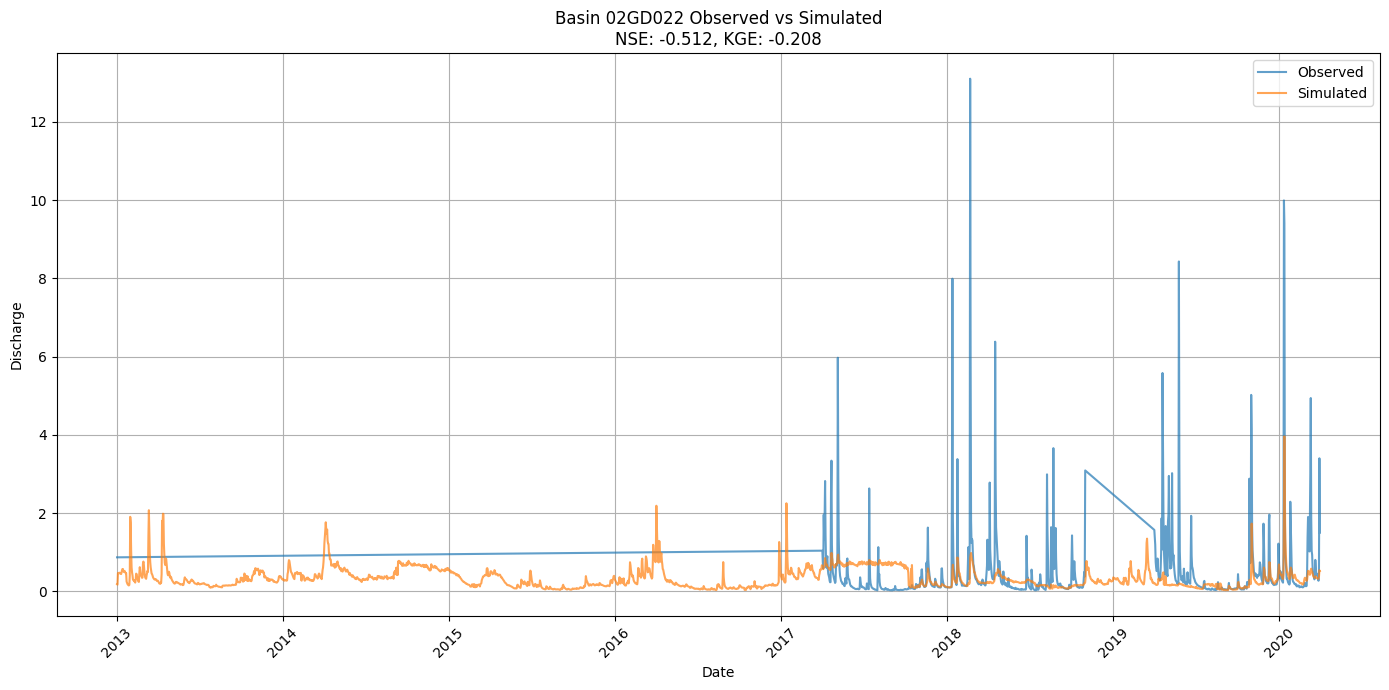

In [54]:
evaluator.plot_prediction('02GD022')

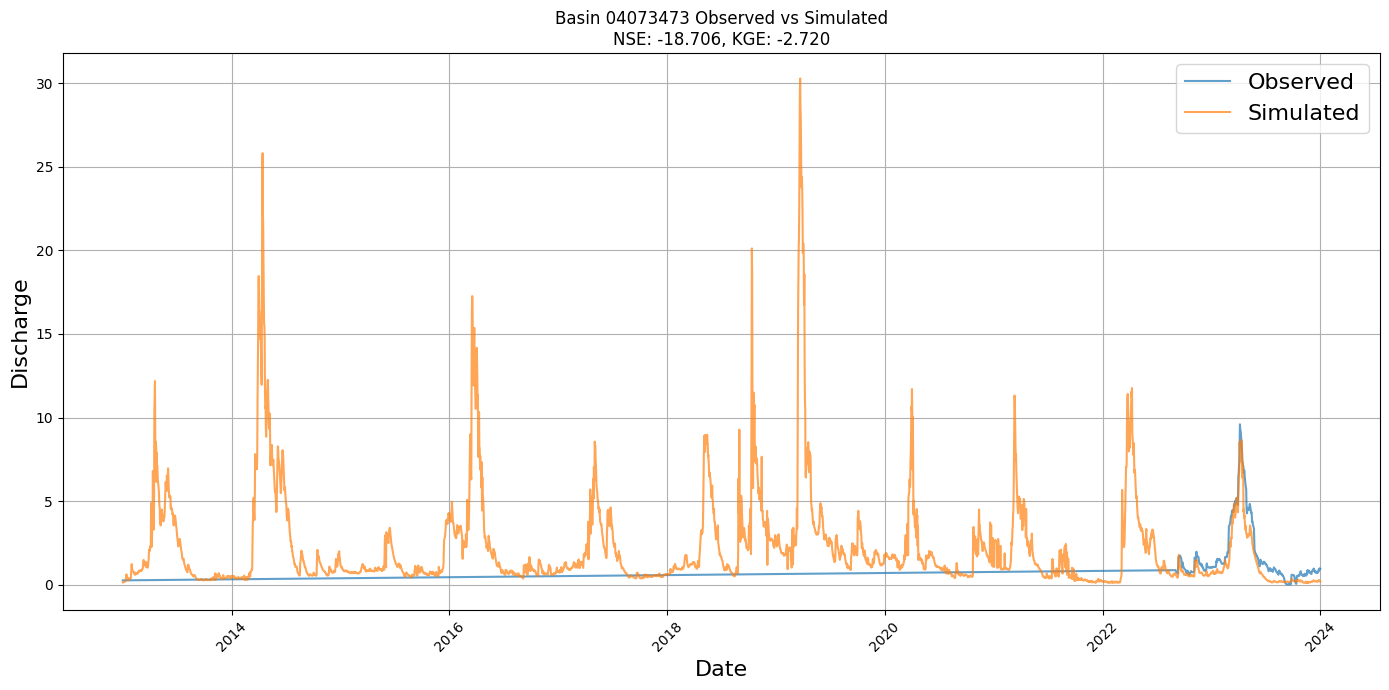

In [38]:
evaluator.plot_prediction('04073473', legend_fontsize=16, x_label_fontsize=16, y_label_fontsize=16)

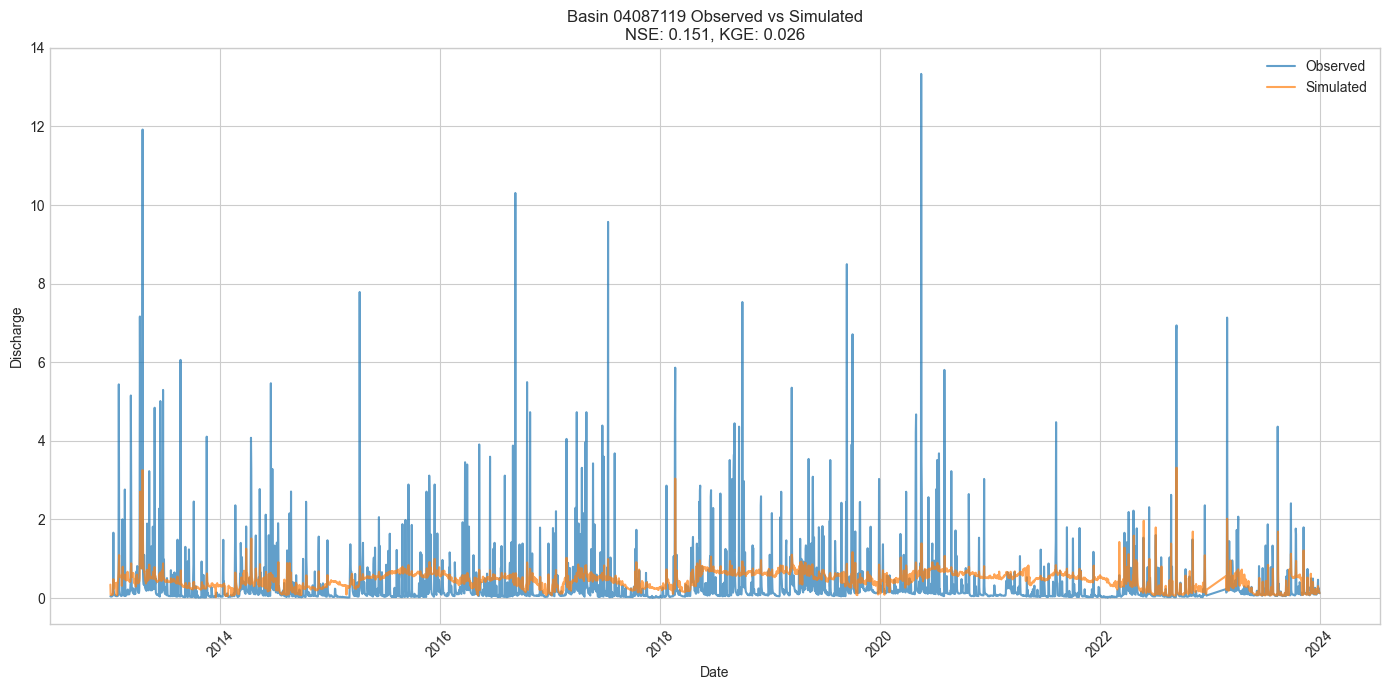

In [60]:
evaluator.plot_prediction('04087119')

In [14]:
evaluator.get_prediction('02DD030')

(-274.49757647340454,
 -15.0725865271265,
 array([234.43242 , 241.96829 , 247.82047 , 239.12056 , 236.96246 ,
        243.27269 , 234.8755  , 233.27113 , 231.24147 , 226.31978 ,
        217.8158  , 223.81718 , 218.52338 , 224.289   , 212.76079 ,
        219.48691 , 211.9297  , 218.41628 , 205.54144 , 210.57379 ,
        205.29433 , 205.41142 , 211.76309 , 204.03093 , 209.37646 ,
        208.71439 , 215.62805 , 205.063   , 205.22192 , 199.96991 ,
        192.93724 , 187.32797 , 181.6423  , 177.07608 , 170.49437 ,
        166.1332  , 158.75015 , 162.78403 , 158.87895 , 156.31798 ,
        162.54735 , 158.19328 , 157.94162 , 156.02713 , 159.2998  ,
        156.11316 , 163.90218 , 159.87582 , 153.64941 , 155.3933  ,
        154.0559  , 149.8111  , 153.43645 , 149.55577 , 145.75137 ,
        140.00235 , 146.37193 , 141.36952 , 145.87056 , 139.7974  ,
        139.15054 , 136.78555 , 141.73035 , 138.47084 , 139.67812 ,
        139.52043 , 134.87105 , 133.4633  , 135.82133 , 131.60414 ,
      

In [58]:
thresh = metrics['NSE'].nsmallest(50).max()
metrics[metrics['NSE'] <= thresh].sort_values('NSE', ascending=True)


,basin_id,NSE
140,02DD030,-274.497576
141,02DD031,-46.461361
653,04073473,-18.705931
24,02AB025,-17.430997
764,04123500,-10.702620
807,04149000,-6.703915
718,04102776,-5.828249
730,04106500,-5.215038
69,02CC008,-3.333878
809,04150500,-3.107481


## Temporal LSTM Model

In [5]:
import pandas as pd

lstm_temporal_result = pd.read_csv("notebooks/results/LSTM_temporal_result.csv")

exclude_ids = [
    "02DD030", "04073473", "02AB025", "04149000", "04102776",
    "04106500", "02CC008", "04150500", "04106320", "04145000",
    "02HB030", "02GD022", "04232100", "02GC021", "02GA050",
]

lstm_temporal_result = lstm_temporal_result[~lstm_temporal_result["basin_id"].isin(exclude_ids)]


In [7]:
lstm_temporal_result.describe()

,Unnamed: 0,NSE,KGE
count,960.000000,632.000000,632.000000
mean,486.348958,-0.051353,0.443766
std,281.444461,6.629722,0.765648
min,0.000000,-120.961717,-12.147390
25%,242.750000,0.396933,0.335302
50%,486.500000,0.572030,0.560072
75%,729.500000,0.683121,0.717523
max,974.000000,0.836027,0.903372


In [9]:
category_counts = lstm_temporal_result["Performance"].value_counts()
print(category_counts)


Performance
Good              436
Unsatisfactory     86
Excellent          57
Negative           53
Name: count, dtype: int64


## Regional Model with Climate Regime Split

In [1]:
import pandas as pd
attributes = pd.read_csv("metadata/attributes.csv")

In [2]:
import pandas as pd
import numpy as np

# Load attributes with monthly precipitation (mm)
attributes = pd.read_csv("metadata/attributes.csv")

# Compute mean annual precipitation across 12 months
precip_cols = [f"pre_mm_s{i:02d}" for i in range(1, 13)]
attributes["mean_prcp"] = attributes[precip_cols].mean(axis=1)

# Load evaluation gauge list (~960 gauges)
with open("basin_list/evaluation_list.txt") as f:
    eval_gauges = [line.strip() for line in f if line.strip()]

# Filter attributes to evaluation gauges only
df = attributes[attributes["gauge_id"].astype(str).isin(eval_gauges)].copy()

# Sort by mean precipitation
df = df.sort_values("mean_prcp").reset_index(drop=True)

# Create 5 equal-sized bins by precipitation
df["bin"] = pd.qcut(df["mean_prcp"], q=5, labels=False)

# Sample 20% from each bin for test set
test_ids = []
train_ids = []

rng = np.random.default_rng(seed=42)  # for reproducibility
for b in range(5):
    bin_df = df[df["bin"] == b]
    test_sample = bin_df.sample(frac=0.2, random_state=42)
    train_sample = bin_df.drop(test_sample.index)

    test_ids.extend(test_sample["gauge_id"].astype(str).tolist())
    train_ids.extend(train_sample["gauge_id"].astype(str).tolist())

# Save to text files
with open("prcp_test.txt", "w") as f:
    f.write("\n".join(test_ids))

with open("prcp_train.txt", "w") as f:
    f.write("\n".join(train_ids))

print(f"Total gauges: {len(df)}")
print(f"Train: {len(train_ids)}, Test: {len(test_ids)}")


Total gauges: 960
Train: 770, Test: 190


In [3]:
# Show bin ranges
bin_ranges = df.groupby("bin")["mean_prcp"].agg(["min", "max", "count"]).reset_index()
print(bin_ranges)


   bin        min         max  count
0    0  59.881575   67.040511    192
1    1  67.060398   70.685522    192
2    2  70.709029   75.280528    192
3    3  75.297873   79.532984    192
4    4  79.555677  109.215264    192


In [ ]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EALSTM_prcp_split_1809_203359" # Specify the model name
epoch_num = 4 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/prcp_test.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=False,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator)

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\neuralhydrology\evaluation\tester.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub f

# Evaluation:   0%|          | 0/190 [00:00<?, ?it/s]

# Evaluation: 100%|██████████| 190/190 [05:22<00:00,  1.70s/it]


  0%|          | 0/190 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  2%|▏         | 4/190 [00:00<00:09, 19.70it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

Summary for: evaluate EALSTM_prcp_split_1809_143455 epoch 3

NSE Summary Statistics: 
count    163.000000
mean      -0.009803
std        1.798063
min      -21.205076
25%        0.103683
50%        0.251011
75%        0.409184
max        0.653848
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    163.000000
mean       0.206716
std        0.413604
min       -3.516655
25%        0.040393
50%        0.276366
75%        0.438828
max        0.773546
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Unsatisfactory    76
Good              59
Negative          28
N/A               27
Name: count, dtype: int64

evaluate EALSTM_prcp_split_1809_143455 epoch 3


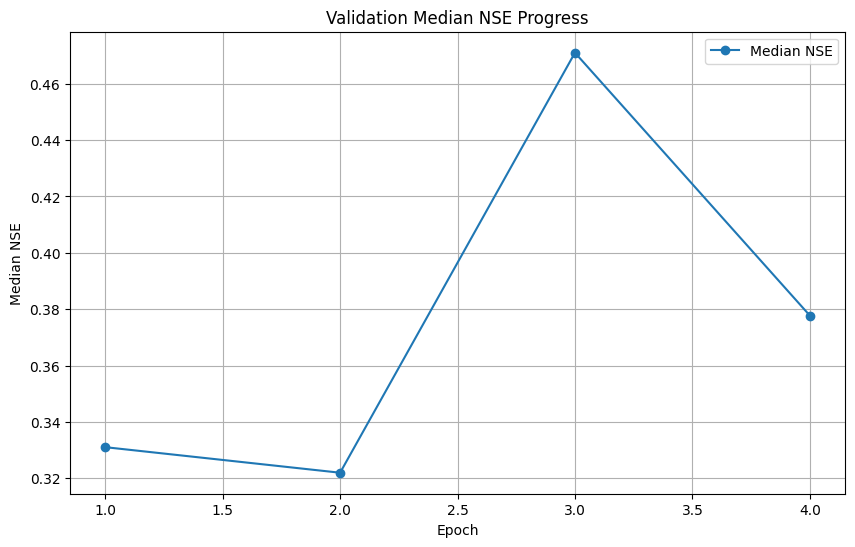

In [3]:
evaluator.plot_validation()

## Simulated Q Heatmap

In [1]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EA-LSTM_Basin_Normalized_2706_143800" # Specify the model name
epoch_num = 33 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/evaluation_list.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/2013",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator)

  0%|          | 0/960 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/960 [00:00<02:04,  7.72it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

Summary for: evaluate EA-LSTM_Basin_Normalized_2706_143800 epoch 33

NSE Summary Statistics: 
count    632.000000
mean       0.528899
std        1.941023
min      -46.461361
25%        0.547301
50%        0.690514
75%        0.769388
max        0.897667
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    632.000000
mean       0.626388
std        0.302567
min       -4.609220
25%        0.534318
50%        0.685321
75%        0.793594
max        0.933572
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Good              362
N/A               328
Excellent         204
Unsatisfactory     51
Negative           15
Name: count, dtype: int64

evaluate EA-LSTM_Basin_Normalized_2706_143800 epoch 33


Running refined water balance check (P - T_proxy vs. Q)...


  0%|          | 0/960 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/960 [00:00<01:45,  9.05it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

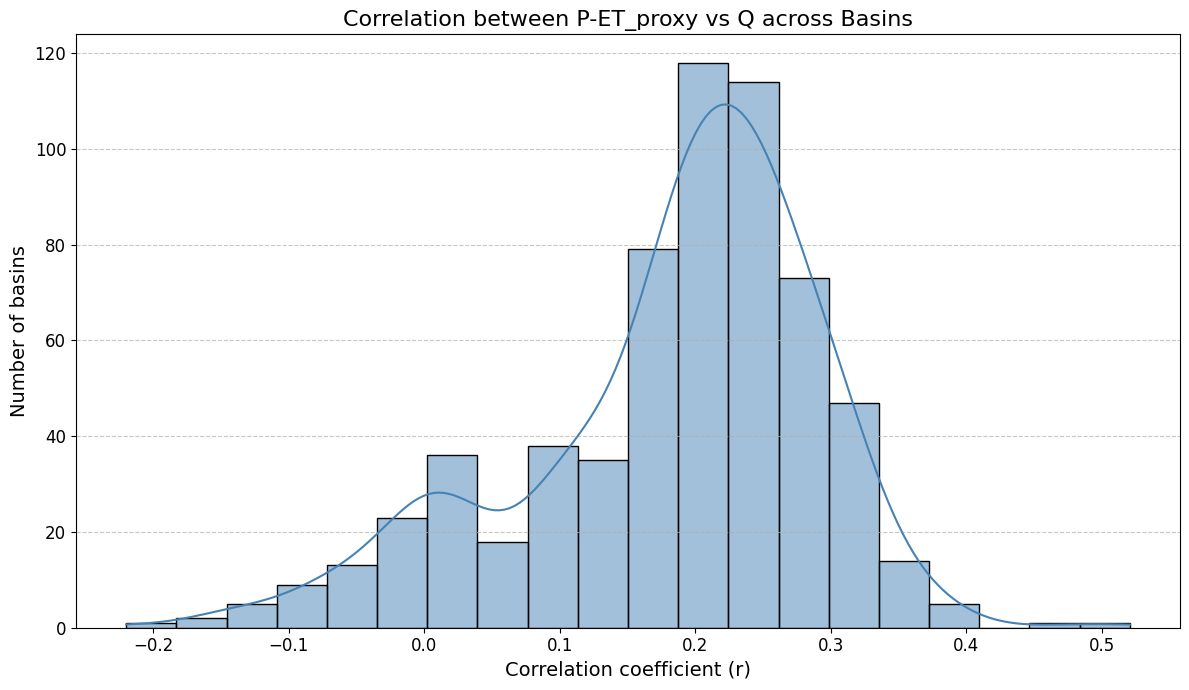

Identifying snow-dominated basins...


  0%|          | 0/960 [00:00<?, ?it/s]c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\util\Evaluator.py:553: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  avg_annual_swe = df_force['swe'].resample('Y').sum().mean()
c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\util\Evaluator.py:554: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  avg_annual_prcp = df_force['prcp'].resample('Y').sum().mean()
c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\util\Evaluator.py:553: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  avg_annual_swe = df_force['swe'].resample('Y').sum().mean()
c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\util\Evaluator.py:554: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  avg_annual_prcp = df_force['prcp'].resample('Y').sum().mean()
c:\Users\ybrot\De

Found 960 snow-dominated basins (Index > 0.2).
Running SWE-Q lag correlation on snow-dominated basins...


  0%|          | 0/960 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/960 [00:00<04:13,  3.78it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

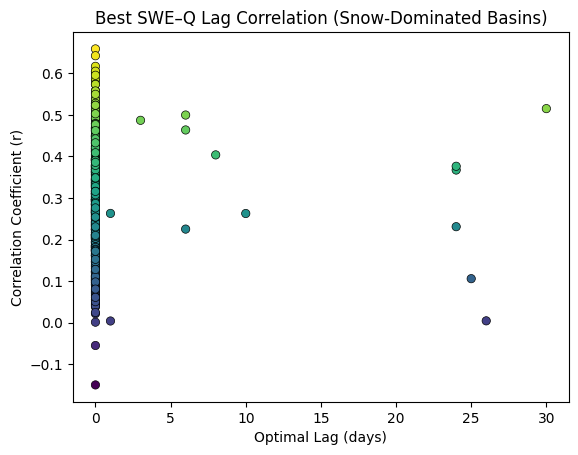

Error: Column 'corr_P_Q' not found in the DataFrame.


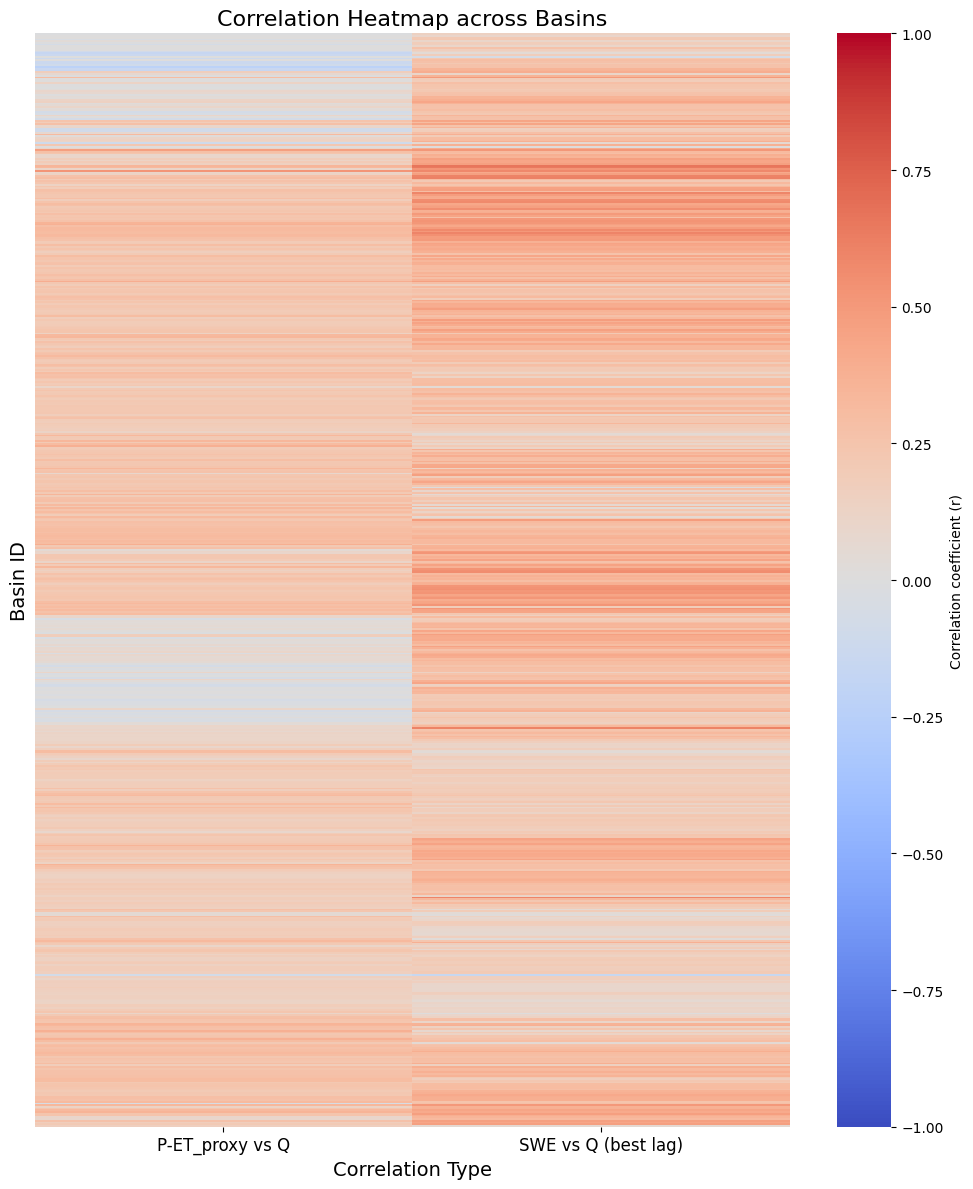

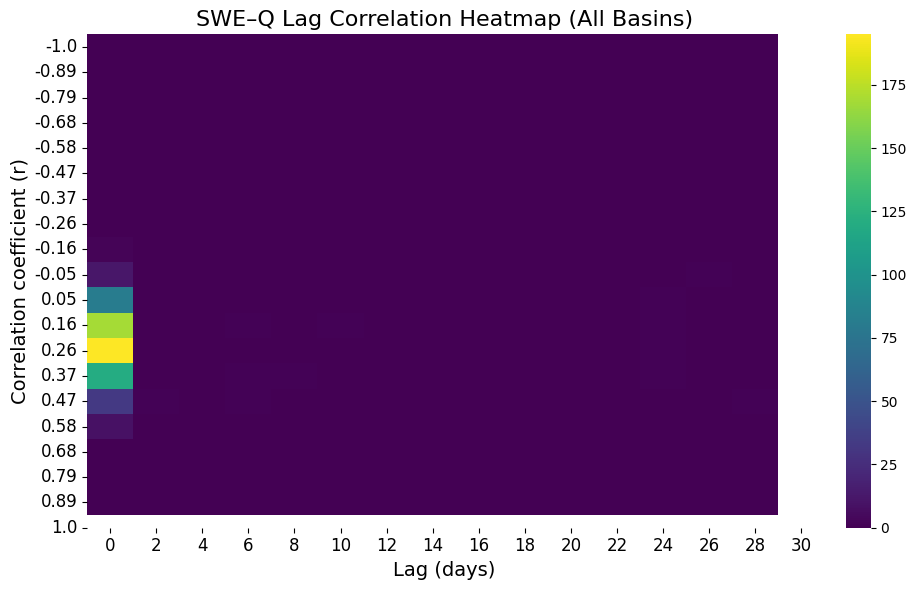

In [2]:
# After you compute correlations:
df_corr = evaluator.plot_water_balance_correlation(forcing_dir="metadata/csv_filtered")
df_swe  = evaluator.plot_snow_lag_correlation(forcing_dir="metadata/csv_filtered", max_lag=30)

# 1. Histogram
evaluator.plot_correlation_histogram(df_corr)

# 2. Heatmap (Precip vs Q, SWE vs Q best lag)
evaluator.plot_correlation_heatmap(df_corr, df_swe)

# 3. SWE Lag Heatmap
evaluator.plot_swe_lag_heatmap(df_swe, max_lag=30)


Running refined water balance check (P - T_proxy vs. Q)...


  0%|          | 0/960 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/960 [00:00<04:24,  3.63it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

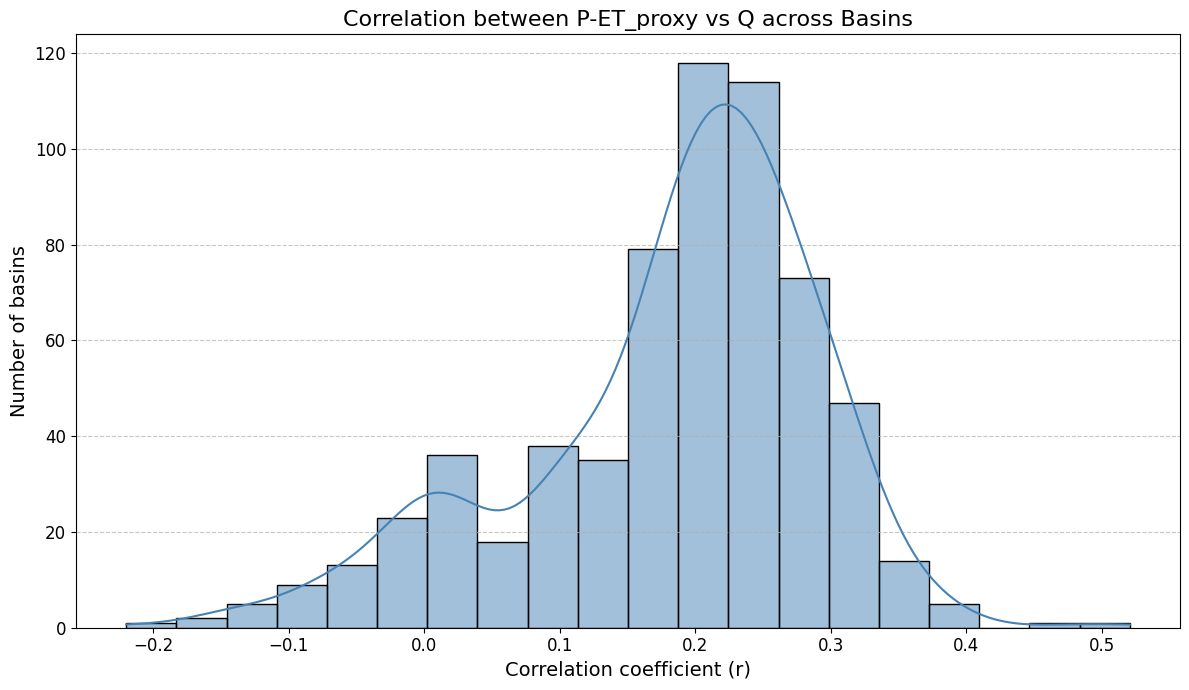

Identifying snow-dominated basins...


  0%|          | 0/960 [00:00<?, ?it/s]c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\util\Evaluator.py:553: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  avg_annual_swe = df_force['swe'].resample('Y').sum().mean()
c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\util\Evaluator.py:554: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  avg_annual_prcp = df_force['prcp'].resample('Y').sum().mean()
c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\util\Evaluator.py:553: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  avg_annual_swe = df_force['swe'].resample('Y').sum().mean()
c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\util\Evaluator.py:554: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  avg_annual_prcp = df_force['prcp'].resample('Y').sum().mean()
c:\Users\ybrot\De

Found 960 snow-dominated basins (Index > 0.2).
Running SWE-Q lag correlation on snow-dominated basins...


  0%|          | 0/960 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/960 [00:00<02:24,  6.62it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

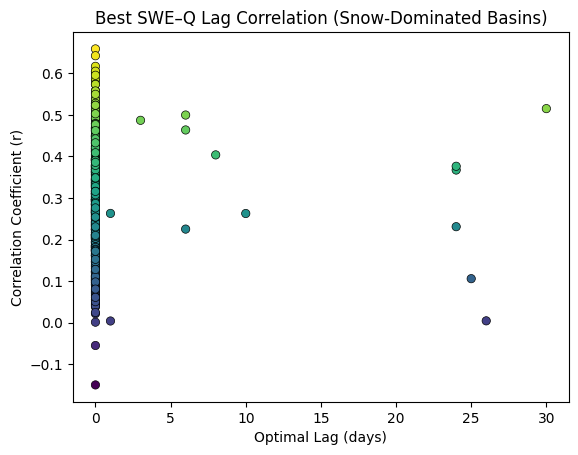

Generating plots with default font sizes...


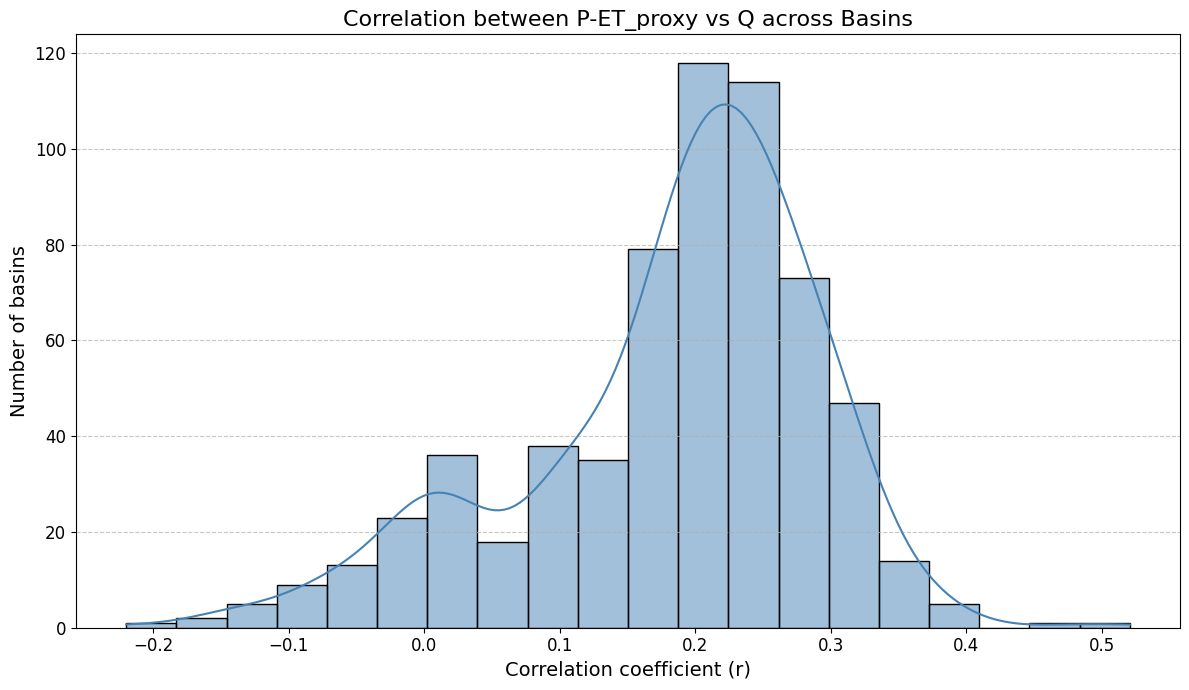

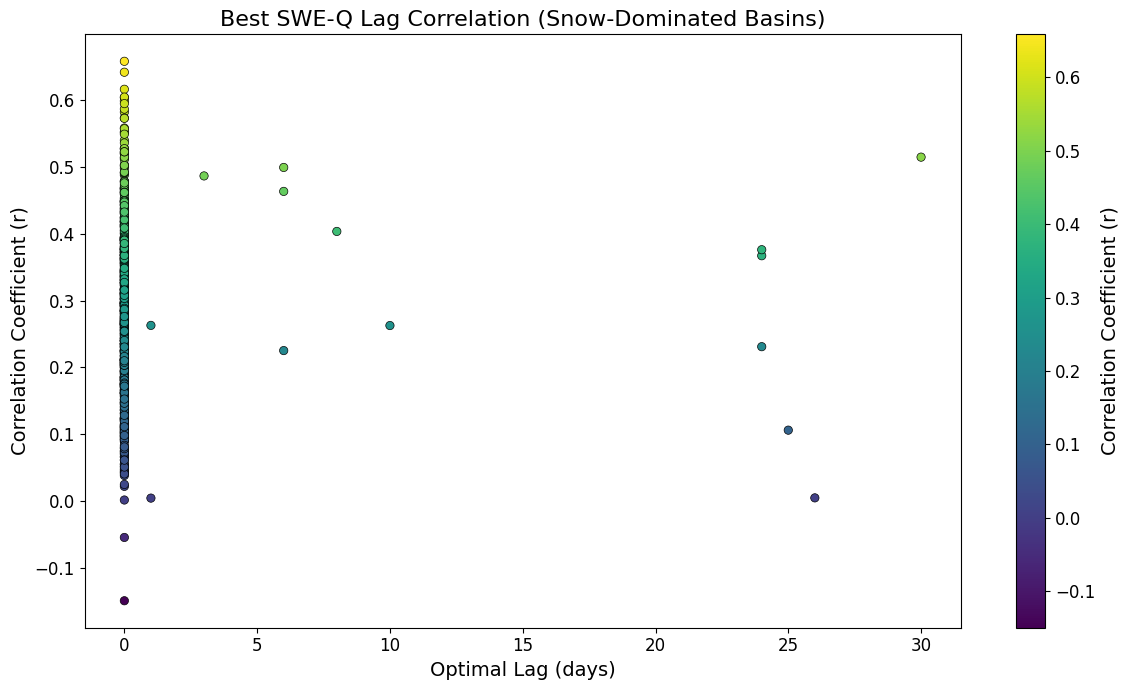


Generating plots with larger font sizes...


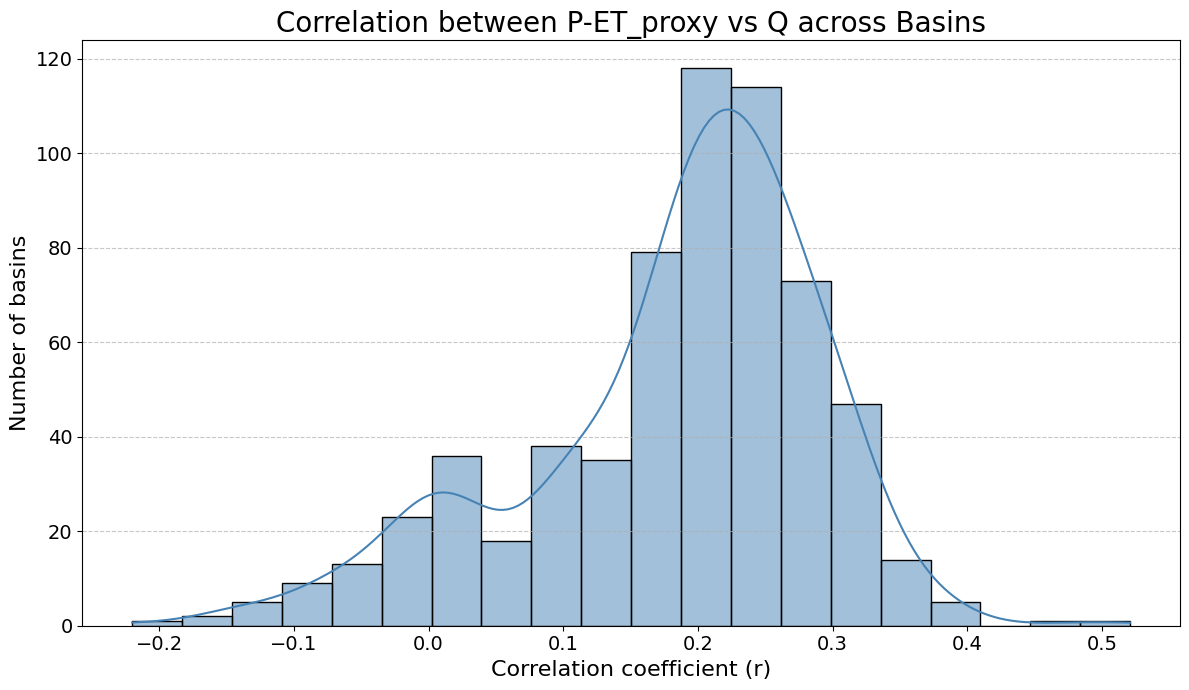

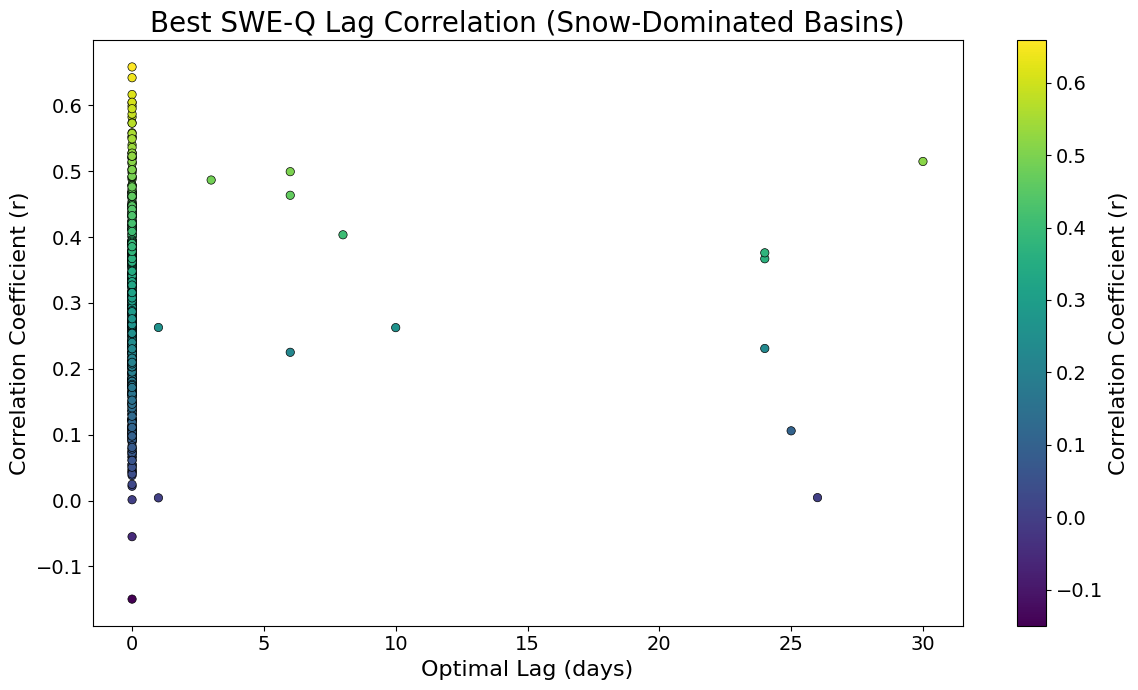

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# You would first load your dataframes 'df_corr' and 'df_swe' here.
# For demonstration, let's create some sample data.
df_corr = evaluator.plot_water_balance_correlation(forcing_dir="metadata/csv_filtered")
df_swe  = evaluator.plot_snow_lag_correlation(forcing_dir="metadata/csv_filtered", max_lag=30)


def plot_correlation_histogram(df_corr,
                               figsize=(12, 7),
                               title_fontsize=16,
                               label_fontsize=14,
                               tick_fontsize=12):
    """
    Plots a histogram of correlation coefficients.

    Args:
        df_corr (pd.DataFrame): DataFrame with correlation values.
        figsize (tuple): The size of the figure.
        title_fontsize (int): Font size for the plot title.
        label_fontsize (int): Font size for the axis labels.
        tick_fontsize (int): Font size for the axis tick labels.
    """
    plt.figure(figsize=figsize)
    
    sns.histplot(df_corr['corr_P_minus_ET_Q'], bins=20, kde=True, color="steelblue", edgecolor="black")

    plt.title("Correlation between P-ET_proxy vs Q across Basins", fontsize=title_fontsize)
    plt.xlabel("Correlation coefficient (r)", fontsize=label_fontsize)
    plt.ylabel("Number of basins", fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_swe_lag_scatter(df_swe,
                         figsize=(12, 7),
                         title_fontsize=16,
                         label_fontsize=14,
                         tick_fontsize=12):
    """
    Plots a scatter plot of SWE-Q lag correlations with a color bar.

    Args:
        df_swe (pd.DataFrame): DataFrame with SWE lag correlation values.
        figsize (tuple): The size of the figure.
        title_fontsize (int): Font size for the plot title.
        label_fontsize (int): Font size for the axis labels.
        tick_fontsize (int): Font size for the axis tick labels.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Define the colormap and normalization for the color bar
    cmap = 'viridis'
    norm = Normalize(vmin=df_swe['best_corr'].min(), vmax=df_swe['best_corr'].max())

    sns.scatterplot(
        data=df_swe,
        x="best_lag",
        y="best_corr",
        hue="best_corr",  # Color points by correlation value
        palette=cmap,
        hue_norm=norm,
        edgecolor="k",
        legend=False,     # Turn off the default legend
        ax=ax
    )

    # Create and add the color bar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) # You need this for the color bar to work properly
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Correlation Coefficient (r)', size=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    ax.set_title("Best SWE-Q Lag Correlation (Snow-Dominated Basins)", fontsize=title_fontsize)
    ax.set_xlabel("Optimal Lag (days)", fontsize=label_fontsize)
    ax.set_ylabel("Correlation Coefficient (r)", fontsize=label_fontsize)
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    plt.tight_layout()
    plt.show()


# --- Example Usage ---
print("Generating plots with default font sizes...")
plot_correlation_histogram(df_corr)
plot_swe_lag_scatter(df_swe)

print("\nGenerating plots with larger font sizes...")
plot_correlation_histogram(df_corr, title_fontsize=20, label_fontsize=16, tick_fontsize=14)
plot_swe_lag_scatter(df_swe, title_fontsize=20, label_fontsize=16, tick_fontsize=14)

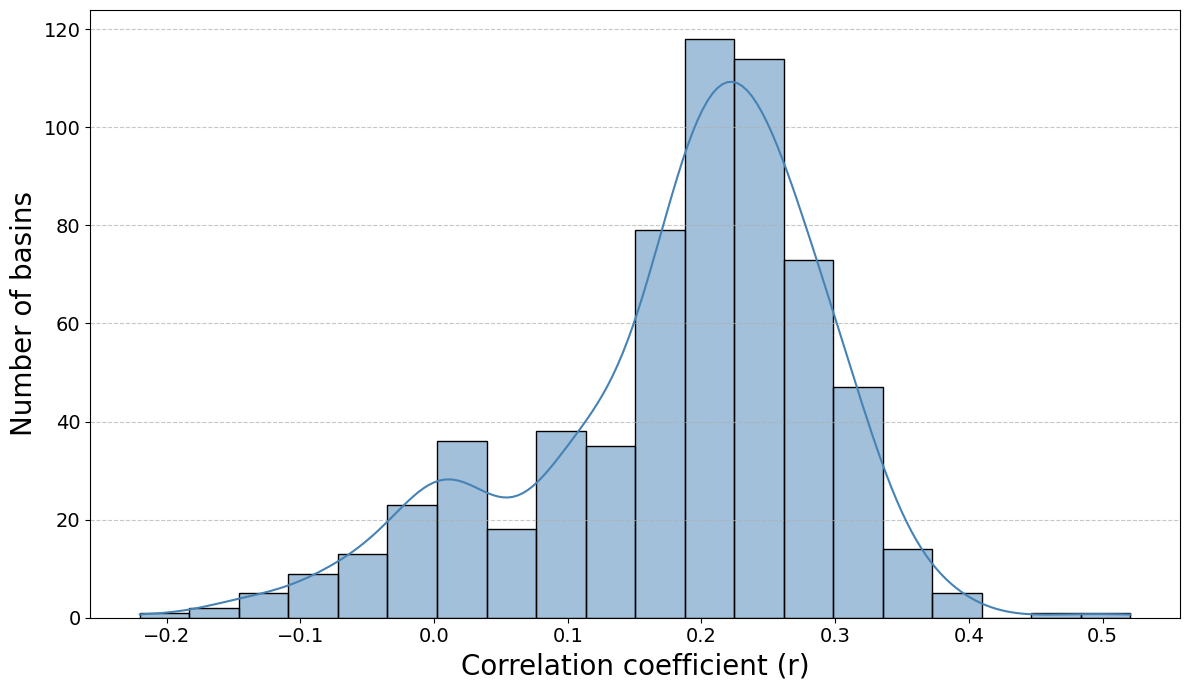

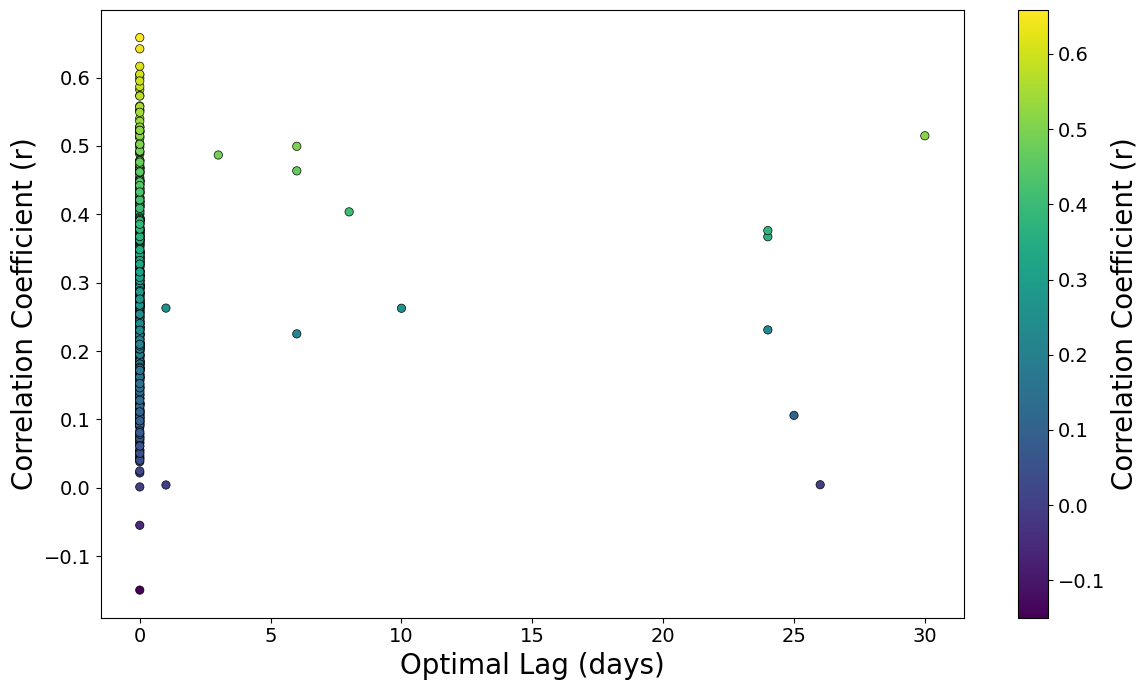

In [12]:
def plot_correlation_histogram(df_corr,
                               figsize=(12, 7),
                               title_fontsize=16,
                               label_fontsize=14,
                               tick_fontsize=12):
    """
    Plots a histogram of correlation coefficients.

    Args:
        df_corr (pd.DataFrame): DataFrame with correlation values.
        figsize (tuple): The size of the figure.
        title_fontsize (int): Font size for the plot title.
        label_fontsize (int): Font size for the axis labels.
        tick_fontsize (int): Font size for the axis tick labels.
    """
    plt.figure(figsize=figsize)
    
    sns.histplot(df_corr['corr_P_minus_ET_Q'], bins=20, kde=True, color="steelblue", edgecolor="black")

    plt.title("", fontsize=title_fontsize)
    plt.xlabel("Correlation coefficient (r)", fontsize=label_fontsize)
    plt.ylabel("Number of basins", fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_swe_lag_scatter(df_swe,
                         figsize=(12, 7),
                         title_fontsize=16,
                         label_fontsize=14,
                         tick_fontsize=12):
    """
    Plots a scatter plot of SWE-Q lag correlations with a color bar.

    Args:
        df_swe (pd.DataFrame): DataFrame with SWE lag correlation values.
        figsize (tuple): The size of the figure.
        title_fontsize (int): Font size for the plot title.
        label_fontsize (int): Font size for the axis labels.
        tick_fontsize (int): Font size for the axis tick labels.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Define the colormap and normalization for the color bar
    cmap = 'viridis'
    norm = Normalize(vmin=df_swe['best_corr'].min(), vmax=df_swe['best_corr'].max())

    sns.scatterplot(
        data=df_swe,
        x="best_lag",
        y="best_corr",
        hue="best_corr",  # Color points by correlation value
        palette=cmap,
        hue_norm=norm,
        edgecolor="k",
        legend=False,     # Turn off the default legend
        ax=ax
    )

    # Create and add the color bar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) # You need this for the color bar to work properly
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Correlation Coefficient (r)', size=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    ax.set_title("", fontsize=title_fontsize)
    ax.set_xlabel("Optimal Lag (days)", fontsize=label_fontsize)
    ax.set_ylabel("Correlation Coefficient (r)", fontsize=label_fontsize)
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    plt.tight_layout()
    plt.show()
    
plot_correlation_histogram(df_corr, title_fontsize=20, label_fontsize=20, tick_fontsize=14)
plot_swe_lag_scatter(df_swe, title_fontsize=20, label_fontsize=20, tick_fontsize=14)

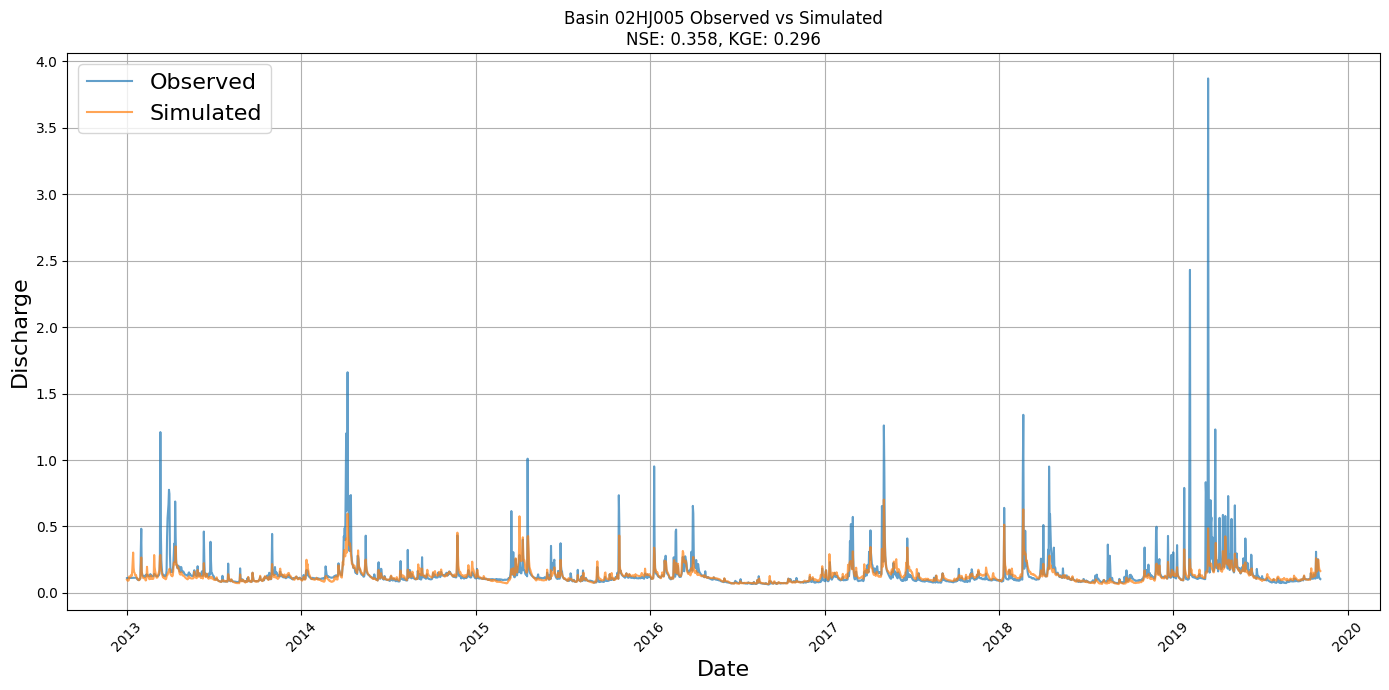

In [9]:
evaluator.plot_prediction("02HJ005", x_label_fontsize=16, y_label_fontsize=16, legend_fontsize=16)

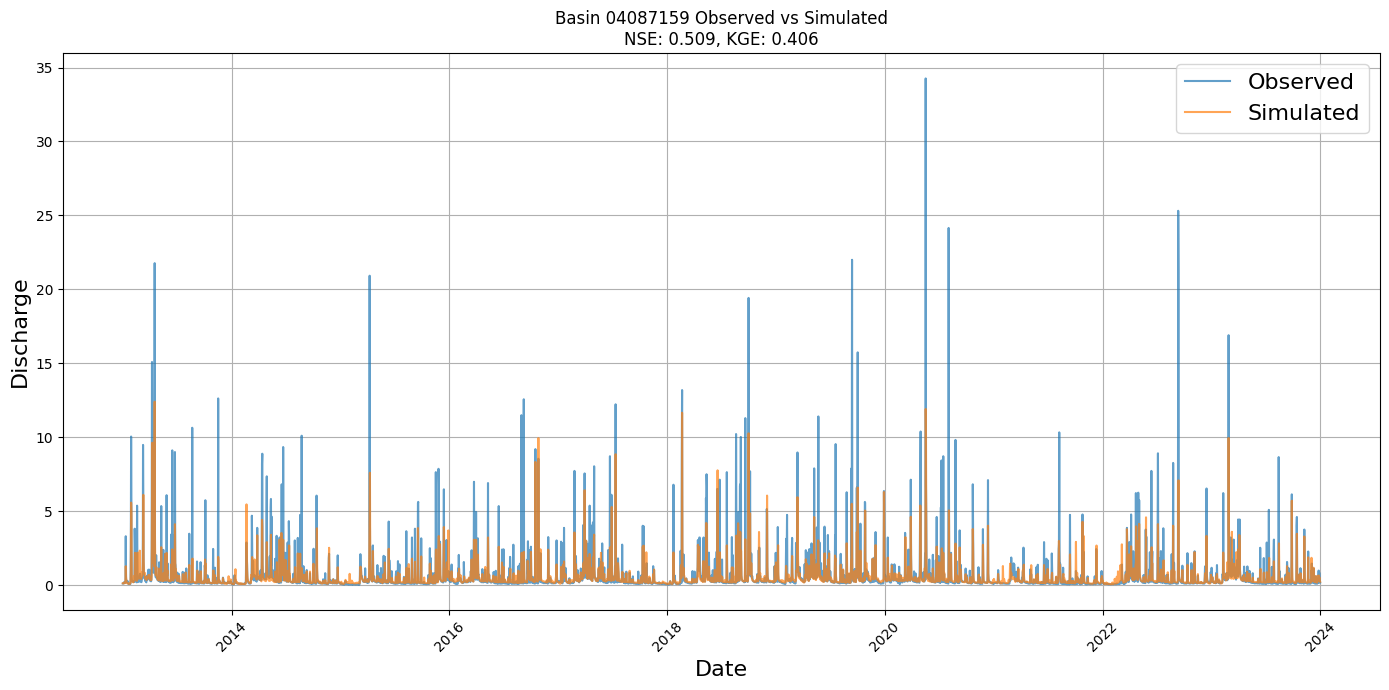

In [10]:
evaluator.plot_prediction("04087159", x_label_fontsize=16, y_label_fontsize=16, legend_fontsize=16)

In [11]:
def find_storm_dates(basin_id, forcing_dir="metadata/csv_filtered", threshold=20):
    """
    Find candidate storm dates where daily precipitation exceeds threshold (mm).
    """
    df = pd.read_csv(f"{forcing_dir}/{basin_id}.csv", parse_dates=['date'])
    storms = df[df['prcp'] > threshold]
    return storms['date'].dt.strftime("%Y-%m-%d").tolist()

# Example usage
storm_dates_small = find_storm_dates("02HJ005", threshold=20)
storm_dates_urban = find_storm_dates("04087159", threshold=20)

print("Candidate storm dates (small basin):", storm_dates_small[:5])
print("Candidate storm dates (urban basin):", storm_dates_urban[:5])

Candidate storm dates (small basin): ['1980-01-11', '1980-03-21', '1980-04-08', '1980-04-14', '1980-06-26']
Candidate storm dates (urban basin): ['1980-06-05', '1980-07-26', '1980-08-04', '1980-08-07', '1980-08-19']


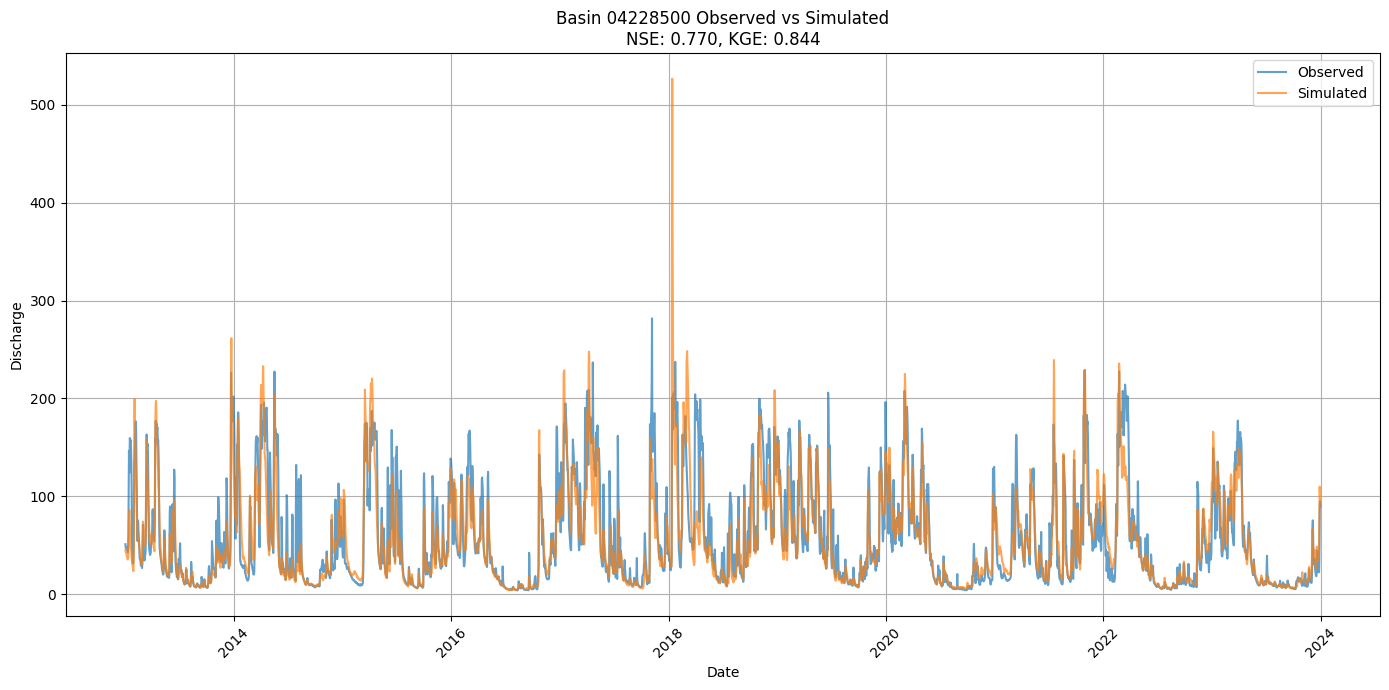

In [25]:
evaluator.plot_prediction("04228500")


--- Generating Case Study for: High-Performing Basin (ID: 04175600) ---


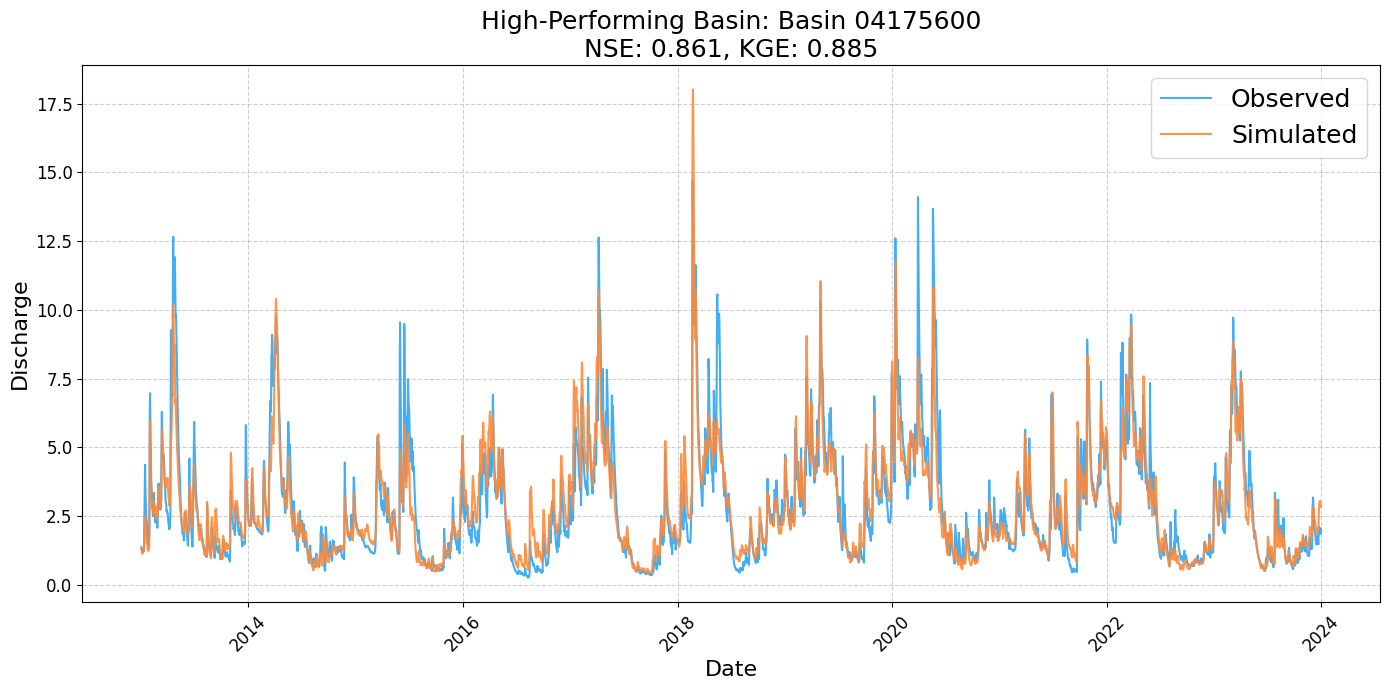


--- Mean Error (Bias) by Observed Flow Quantile ---
0-10%      0.254933
10-20%     0.115443
20-30%     0.160815
30-40%     0.206304
40-50%     0.201021
50-60%     0.202553
60-70%     0.194780
70-80%     0.145458
80-90%    -0.118965
90-100%   -1.001704
--------------------------------------------------



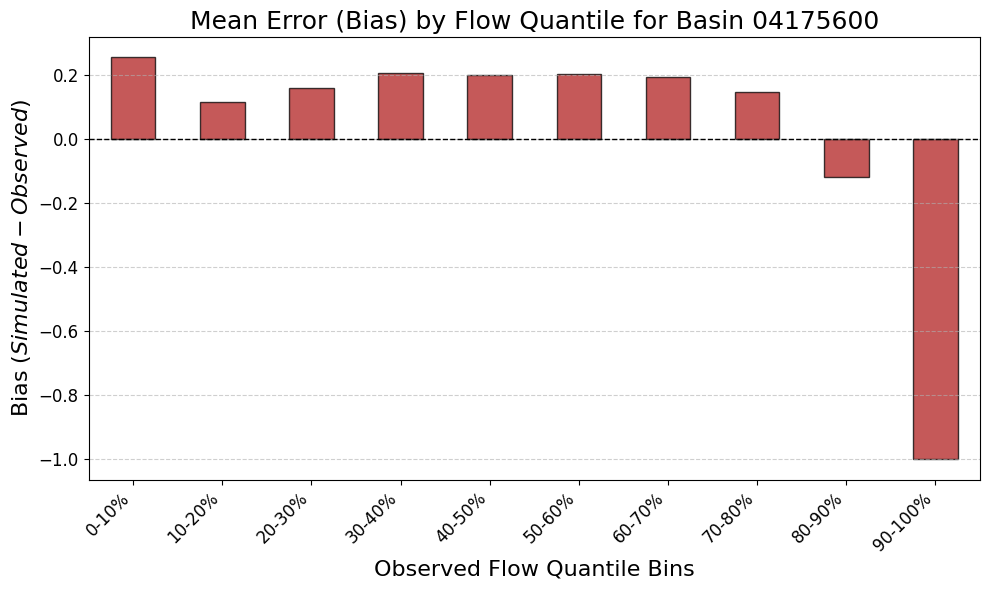

In [34]:
create_case_study_visuals(
        evaluator,
        "04175600",
        "High-Performing Basin",
        title_fontsize=18,
        label_fontsize=16,
        legend_fontsize=18
    )


--- Generating Case Study for: Small Headwater Basin Case Study (ID: 02HJ005) ---


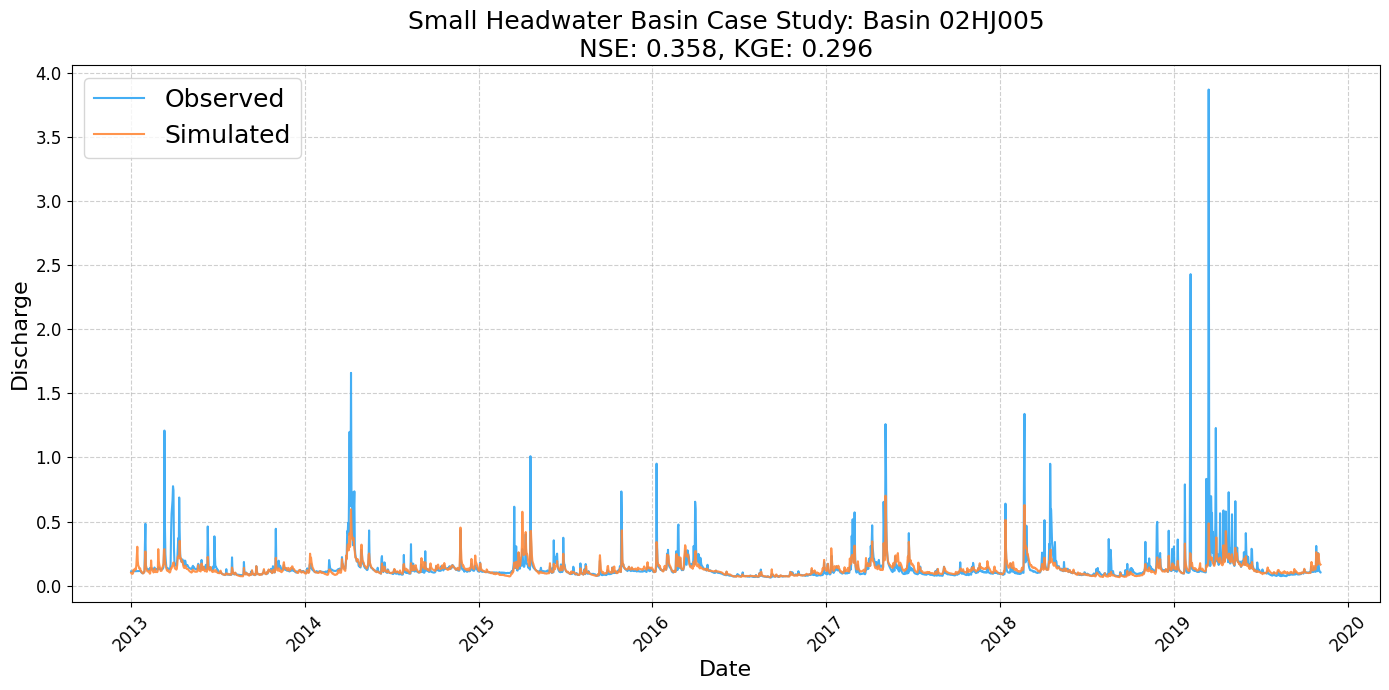


--- Mean Error (Bias) by Observed Flow Quantile ---
0-10%      0.004817
10-20%     0.006349
20-30%     0.006542
30-40%     0.006669
40-50%     0.007364
50-60%     0.010023
60-70%     0.003131
70-80%     0.004420
80-90%    -0.002540
90-100%   -0.170248
--------------------------------------------------



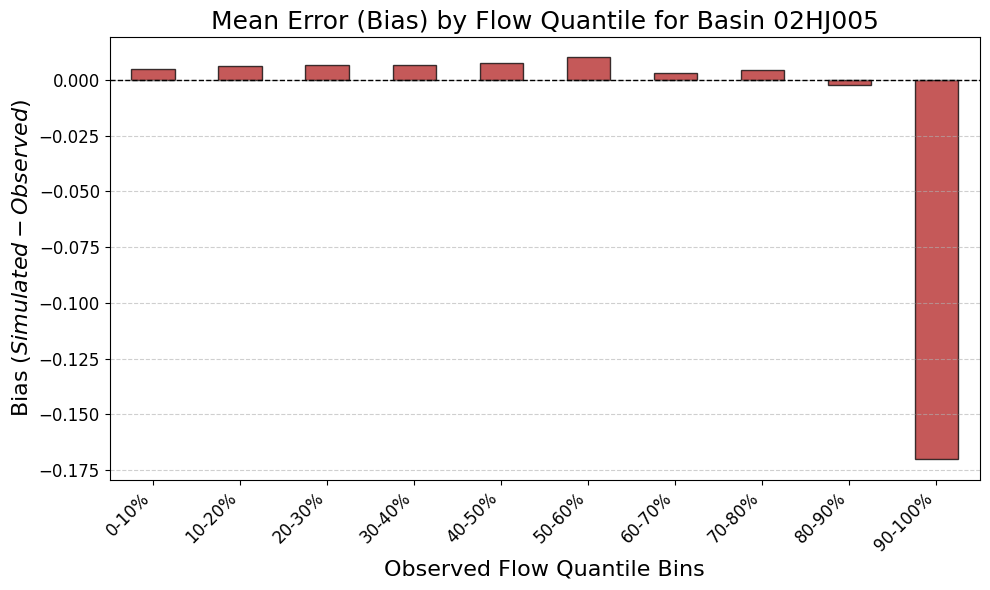


--- Generating Case Study for: Urban Basin Case Study (ID: 04087159) ---


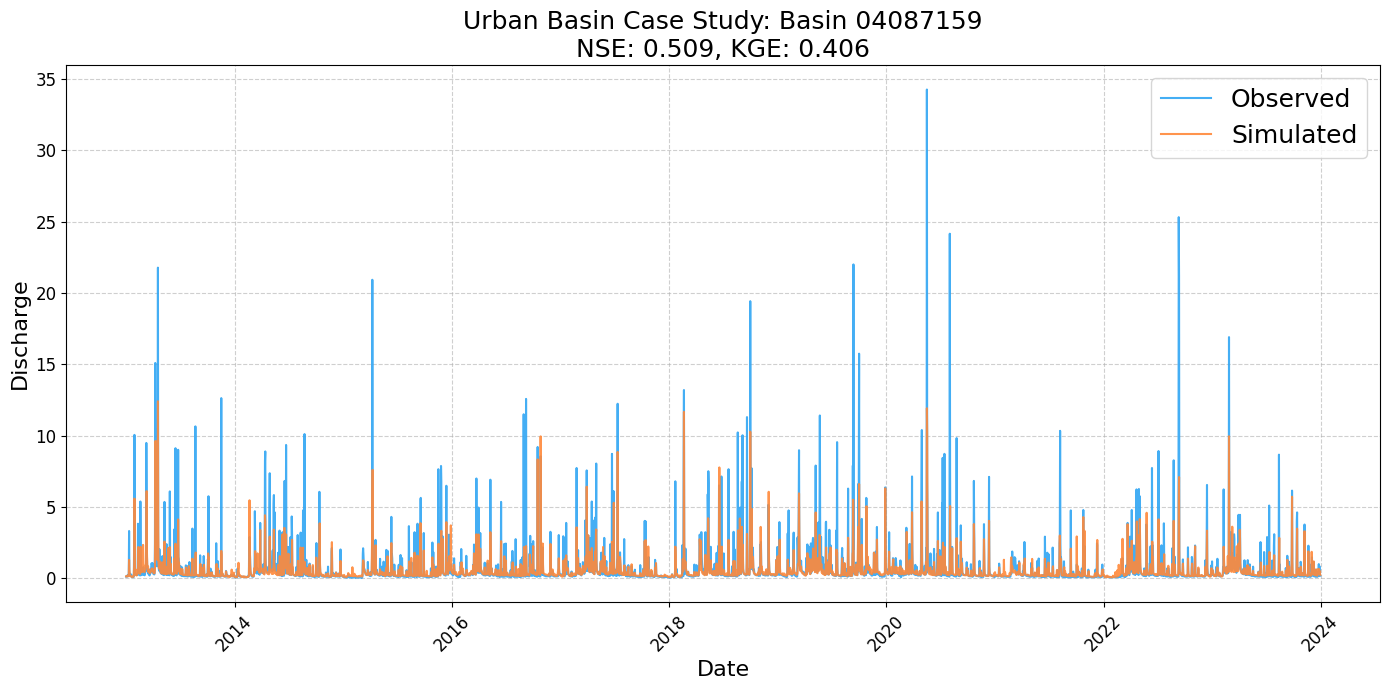


--- Mean Error (Bias) by Observed Flow Quantile ---
0-10%      0.086128
10-20%     0.091340
20-30%     0.087313
30-40%     0.083156
40-50%     0.091777
50-60%     0.091146
60-70%     0.116925
70-80%     0.089589
80-90%    -0.079373
90-100%   -2.159021
--------------------------------------------------



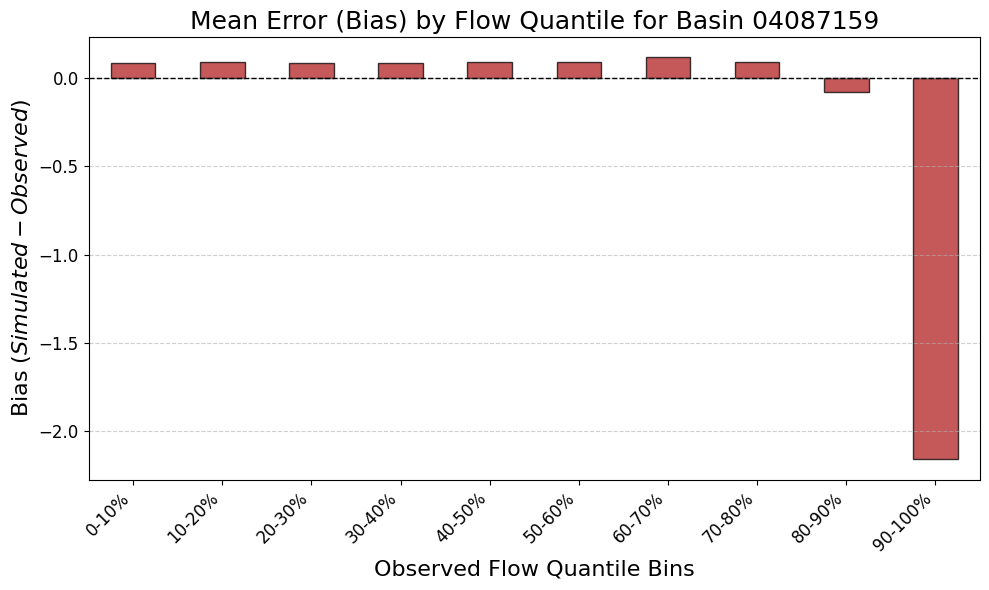


--- Generating Case Study for: Large and Undeveloped Basin Case Study (ID: 04228500) ---


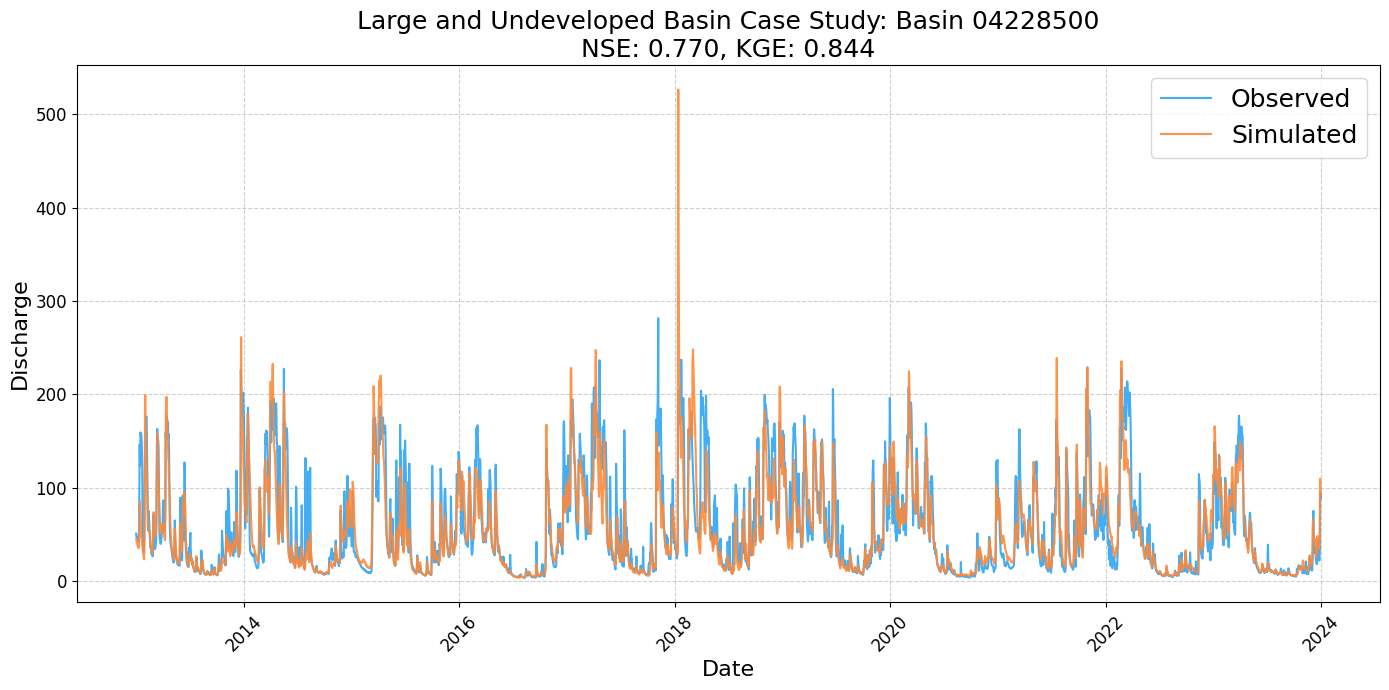


--- Mean Error (Bias) by Observed Flow Quantile ---
0-10%       0.947351
10-20%      1.721834
20-30%      2.638546
30-40%      2.490706
40-50%      4.212896
50-60%      3.581915
60-70%      5.048324
70-80%     -8.247558
80-90%    -16.605547
90-100%   -28.207281
--------------------------------------------------



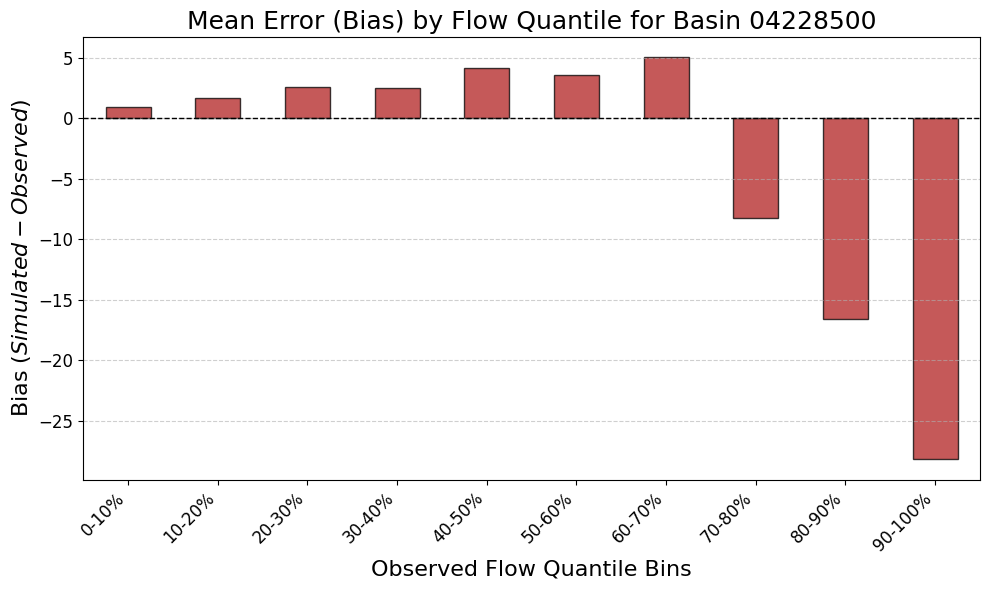

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# This import assumes your Evaluator class is in a 'util' folder.
# Adjust the path if necessary.
from util.Evaluator import Evaluator

def calculate_error_by_quantile(observed: np.ndarray, simulated: np.ndarray, num_quantiles: int = 10):
    """
    Calculates the mean error (bias) for different flow quantiles.
    """
    df = pd.DataFrame({'observed': observed, 'simulated': simulated})
    try:
        df['quantile_bin'] = pd.qcut(df['observed'], q=num_quantiles, labels=False, duplicates='drop')
    except ValueError:
        print("Could not create quantile bins. The data may have too little variance.")
        return None

    df['bias'] = df['simulated'] - df['observed']
    quantile_bias = df.groupby('quantile_bin')['bias'].mean()
    
    labels = []
    num_returned_bins = len(quantile_bias)
    quantiles = np.linspace(0, 1, num_returned_bins + 1)
    for i in range(num_returned_bins):
        labels.append(f'{quantiles[i]*100:.0f}-{quantiles[i+1]*100:.0f}%')
    
    quantile_bias.index = labels
    return quantile_bias


def create_case_study_visuals(evaluator: Evaluator,
                              basin_id: str,
                              case_study_name: str,
                              title_fontsize: int = 16,
                              label_fontsize: int = 14,
                              legend_fontsize: int = 12,
                              tick_fontsize: int = 12):
    """
    Generates a hydrograph plot and quantile error analysis with customizable aesthetics.
    """
    print(f"\n--- Generating Case Study for: {case_study_name} (ID: {basin_id}) ---")

    try:
        nse, kge, sim_q, obs_q, dates = evaluator.get_prediction(basin_id)
        if obs_q is None or len(obs_q) == 0:
            print(f"No data available for basin {basin_id}. Skipping.")
            return
    except Exception as e:
        print(f"Could not retrieve data for basin {basin_id}. Error: {e}")
        return

    # --- Hydrograph Plot ---
    # Using the requested color palette and adjustable font sizes
    plt.figure(figsize=(14, 7))
    plt.plot(dates, obs_q, label='Observed', color="#30A5F3", alpha=0.9)
    plt.plot(dates, sim_q, label='Simulated', color="#FF893A", alpha=0.9)
    
    plt.xlabel('Date', fontsize=label_fontsize)
    plt.ylabel(evaluator.target_var.capitalize(), fontsize=label_fontsize)
    plt.title(f'{case_study_name}: Basin {basin_id}\nNSE: {nse:.3f}, KGE: {kge:.3f}', fontsize=title_fontsize)
    plt.legend(fontsize=legend_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Quantile Error Analysis ---
    quantile_errors = calculate_error_by_quantile(obs_q, sim_q)
    if quantile_errors is not None:
        print("\n--- Mean Error (Bias) by Observed Flow Quantile ---")
        print(quantile_errors.to_string())
        print("--------------------------------------------------\n")

        # --- Quantile Error Bar Chart ---
        plt.figure(figsize=(10, 6))
        quantile_errors.plot(kind='bar', color='firebrick', alpha=0.75, edgecolor='black')
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        
        plt.title(f'Mean Error (Bias) by Flow Quantile for Basin {basin_id}', fontsize=title_fontsize)
        plt.xlabel('Observed Flow Quantile Bins', fontsize=label_fontsize)
        plt.ylabel('Bias ($Simulated - Observed$)', fontsize=label_fontsize)
        plt.xticks(rotation=45, ha="right", fontsize=tick_fontsize)
        plt.yticks(fontsize=tick_fontsize)

        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

if __name__ == '__main__':

    # --- Step 2: Define your case study basins ---
    small_headwater_id = '02HJ005'
    urban_basin_id = '04087159'
    reference_basin_id = "04228500"

    # --- Step 3: Run the analysis for each case study ---
    # You can now easily change the font sizes for each plot call
    create_case_study_visuals(
        evaluator,
        small_headwater_id,
        "Small Headwater Basin Case Study",
        title_fontsize=18,
        label_fontsize=16,
        legend_fontsize=18
    )
    
    create_case_study_visuals(
        evaluator,
        urban_basin_id,
        "Urban Basin Case Study",
        title_fontsize=18,
        label_fontsize=16,
        legend_fontsize=18
    )
    
    create_case_study_visuals(
        evaluator,
        reference_basin_id,
        "Large and Undeveloped Basin Case Study",
        title_fontsize=18,
        label_fontsize=16,
        legend_fontsize=18
    )



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from util.Evaluator import Evaluator  # Assumes your Evaluator class is in 'util/Evaluator.py'

def calculate_error_by_quantile(observed: np.ndarray, simulated: np.ndarray, num_quantiles: int = 10):
    """
    Calculates the mean error (bias) for different flow quantiles.

    Args:
        observed (np.ndarray): Array of observed streamflow values.
        simulated (np.ndarray): Array of simulated streamflow values.
        num_quantiles (int): The number of quantile bins to create (e.g., 10 for deciles).

    Returns:
        pd.Series: A pandas Series with the mean bias for each quantile bin.
    """
    # Create a DataFrame for easier processing
    df = pd.DataFrame({'observed': observed, 'simulated': simulated})
    
    # Define quantile bins based on the observed flow.
    # duplicates='drop' is important for series with many identical values (e.g., zero flows)
    try:
        df['quantile_bin'] = pd.qcut(df['observed'], q=num_quantiles, labels=False, duplicates='drop')
    except ValueError:
        print("Could not create quantile bins. The data may have too little variance.")
        return None

    # Calculate bias (simulated - observed) for each row
    df['bias'] = df['simulated'] - df['observed']
    
    # Group by quantile bin and calculate the mean bias
    quantile_bias = df.groupby('quantile_bin')['bias'].mean()
    
    # Create readable labels for the plot and table
    labels = []
    # Adjust for cases where pd.qcut returns fewer bins than requested
    num_returned_bins = len(quantile_bias)
    quantiles = np.linspace(0, 1, num_returned_bins + 1)
    for i in range(num_returned_bins):
        labels.append(f'{quantiles[i]*100:.0f}-{quantiles[i+1]*100:.0f}%')
    
    quantile_bias.index = labels
    
    return quantile_bias


def create_case_study_visuals(evaluator: Evaluator, basin_id: str, case_study_name: str, storm_date_str: str, window_days: int = 14):
    """
    Generates a comprehensive multi-panel plot for a single basin case study.

    Args:
        evaluator (Evaluator): An initialized instance of your Evaluator class.
        basin_id (str): The ID of the basin to analyze.
        case_study_name (str): A descriptive name for the plot titles.
        storm_date_str (str): The center date for the storm window, e.g., '2015-06-20'.
        window_days (int): The number of days to show in the storm window plot.
    """
    print(f"\n--- Generating Case Study for: {case_study_name} (ID: {basin_id}) ---")

    # 1. Use get_prediction to retrieve simulation data
    try:
        nse, kge, sim_q, obs_q, dates = evaluator.get_prediction(basin_id)
        if obs_q is None or len(obs_q) == 0:
            print(f"No data available for basin {basin_id}. Skipping.")
            return
    except Exception as e:
        print(f"Could not retrieve data for basin {basin_id}. Error: {e}")
        return

    # Create a 3-panel figure
    fig, axes = plt.subplots(3, 1, figsize=(12, 18), gridspec_kw={'height_ratios': [1, 1, 1]})
    fig.suptitle(f'{case_study_name}: Basin {basin_id} (Overall NSE: {nse:.3f}, KGE: {kge:.3f})', fontsize=16)

    # --- Panel 1: Full Hydrograph ---
    axes[0].plot(dates, obs_q, label='Observed', color='k', lw=1.5)
    axes[0].plot(dates, sim_q, label='Simulated', color='royalblue', alpha=0.8, lw=1.5)
    axes[0].set_title('Full Period Hydrograph')
    axes[0].set_ylabel(f'{evaluator.target_var.capitalize()} ($m^3/s$)')
    axes[0].legend()
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- Panel 2: Storm Response Window ---
    storm_center = pd.to_datetime(storm_date_str)
    start_date = storm_center - pd.Timedelta(days=window_days / 2)
    end_date = storm_center + pd.Timedelta(days=window_days / 2)

    df_full = pd.DataFrame({'date': dates, 'obs': obs_q, 'sim': sim_q}).set_index('date')
    df_storm = df_full.loc[start_date:end_date]

    axes[1].plot(df_storm.index, df_storm['obs'], 'o-', label='Observed', color='k', lw=2, markersize=5)
    axes[1].plot(df_storm.index, df_storm['sim'], 'o--', label='Simulated', color='royalblue', alpha=0.8, lw=2, markersize=5)
    axes[1].set_title(f'Storm Response Window (Centered on {storm_date_str})')
    axes[1].set_ylabel(f'{evaluator.target_var.capitalize()} ($m^3/s$)')
    axes[1].legend()
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    # Improve date formatting for the zoomed-in plot
    fig.autofmt_xdate()

    # --- Panel 3: Errors by Flow Quantile ---
    quantile_errors = calculate_error_by_quantile(obs_q, sim_q)
    if quantile_errors is not None:
        quantile_errors.plot(kind='bar', ax=axes[2], color='firebrick', alpha=0.75, edgecolor='k')
        axes[2].axhline(0, color='k', linestyle='--', linewidth=1)
        axes[2].set_title('Mean Error (Bias) by Flow Quantile')
        axes[2].set_xlabel('Observed Flow Quantile Bins')
        axes[2].set_ylabel('Bias ($Simulated - Observed$)')
        axes[2].grid(axis='y', linestyle='--', linewidth=0.5)
        plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

        # Also print the table to the console
        print("\n--- Mean Error (Bias) by Observed Flow Quantile ---")
        print(quantile_errors.to_string())
        print("--------------------------------------------------\n")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust for suptitle
    plt.show()


if __name__ == '__main__':
    

    # --- Step 2: Define your case study basins and storm dates ---
    # IMPORTANT: Replace these with actual IDs and storm dates from your dataset.
    # Look at the full hydrograph (top panel) to find a date for a major peak flow event.
    small_headwater_id = '02FA002'
    small_headwater_storm_date = '2017-04-07' # <-- REPLACE with a peak flow date for this basin

    urban_basin_id = '02GA020'
    urban_basin_storm_date = '2018-02-22'       # <-- REPLACE with a peak flow date for this basin

    # --- Step 3: Run the analysis for each case study ---
    create_case_study_visuals(
        evaluator, 
        small_headwater_id, 
        "Small Headwater Basin Case Study", 
        storm_date_str=small_headwater_storm_date
    )
    
    create_case_study_visuals(
        evaluator, 
        urban_basin_id, 
        "Urban Basin Case Study",
        storm_date_str=urban_basin_storm_date
    )



## Cross-Validation

In [20]:
import pandas as pd

area_result = pd.read_csv("notebooks/results/EALSTM_spatial_result.csv")
print(area_result[['NSE', 'KGE']].describe())

              NSE         KGE
count  168.000000  168.000000
mean    -0.020477    0.435649
std      3.944019    0.560046
min    -47.937880   -4.439254
25%      0.310496    0.354201
50%      0.569357    0.567197
75%      0.714350    0.702287
max      0.853896    0.895602


In [8]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EALSTM_prcp_split_1809_203359" # Specify the model name
epoch_num = 4 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/prcp_test.txt"

# Call the Evaluator Class
evaluator_prcp = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator_prcp)

  0%|          | 0/190 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  3%|▎         | 5/190 [00:00<00:08, 21.41it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

Summary for: evaluate EALSTM_prcp_split_1809_203359 epoch 4

NSE Summary Statistics: 
count    163.000000
mean      -0.413554
std        6.196151
min      -69.688390
25%        0.272436
50%        0.527260
75%        0.662680
max        0.841434
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    163.000000
mean       0.297379
std        1.061588
min       -9.743540
25%        0.286558
50%        0.505339
75%        0.686957
max        0.915184
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Good              93
Unsatisfactory    31
N/A               27
Negative          22
Excellent         17
Name: count, dtype: int64

evaluate EALSTM_prcp_split_1809_203359 epoch 4


In [16]:
evaluator_prcp.get_metrics().to_csv("notebooks/results/EALSTM_spatial_result_prcp.csv")

In [12]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EALSTM_temp_split_1909_145950" # Specify the model name
epoch_num = 6 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/temp_test.txt"

# Call the Evaluator Class
evaluator_temp = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=-0.3934,
                      var=1.2770 ** 2,
                      basin_area_scale_divisor=100,
                      apply_transformation=True,
                      apply_basin_norm=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator_temp)

  1%|          | 1/190 [00:00<00:30,  6.24it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  5%|▍         | 9/190 [00:00<00:14, 12.68it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-pa

Summary for: evaluate EALSTM_temp_split_1909_145950 epoch 6

NSE Summary Statistics: 
count    162.000000
mean       0.186603
std        1.422419
min      -12.149835
25%        0.271314
50%        0.523639
75%        0.687125
max        0.895494
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    162.000000
mean       0.457466
std        0.382588
min       -1.736077
25%        0.325014
50%        0.540745
75%        0.689330
max        0.911968
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Good              80
Unsatisfactory    33
N/A               28
Excellent         26
Negative          23
Name: count, dtype: int64

evaluate EALSTM_temp_split_1909_145950 epoch 6


In [17]:
evaluator_temp.get_metrics().to_csv("notebooks/results/EALSTM_spatial_result_temp.csv")